# CoDA: Agentic Systems for Collaborative Data Visualization 実装例

## 概要

本ノートブックは、論文「[CoDA: Agentic Systems for Collaborative Data Visualization](https://arxiv.org/abs/2510.03194)」に基づくマルチエージェント協調型データ可視化システムの実装例です。Google Agent Development Kit (ADK) と Vertex AI (Gemini モデル) を活用し、ユーザーの自然言語によるリクエストから適切なグラフ画像を自動生成するパイプラインを構築します。

**※実装上の留意点**
元の論文では、生成されたグラフ画像を評価して、修正が必要な際には要件定義やコード生成に立ち戻って再生成を行う「フィードバックループ」の仕組みが含まれています。本実装ではコードの全体像をシンプルに保つため、この画像評価および再生成のループ処理は省略し、一方向の生成パイプラインとして構成しています。同様にコードサンプルの Web 検索機能も省略しています。

## アーキテクチャとエージェント構成

このシステムは、ユーザーとの対話を行うルートエージェントと、可視化の各タスクを専門的に分担する複数のサブエージェント（`SequentialAgent`）によって構成されています。

* **Root Agent (`root_agent`)**: ユーザーと対話し、可視化の要件（可視化クエリ、コンテキスト、対象のCSVファイル名）を漏れなく収集した上で、生成パイプラインを起動します。
* **Query Analyzer (`query_analyzer`)**: ユーザーの意図を解釈し、可視化の全体計画と実装に向けたTODOリストを作成します。
* **Data Process Planner (`data_process_planner`)**: データのメタデータや統計情報をツールを用いて分析し、必要なデータ前処理（変換や集計）のステップを計画します。
* **VizMapping Agent (`viz_mapping_agent`)**: データの各列をグラフの視覚的プロパティ（X軸、Y軸、色など）にマッピングし、最適なチャートタイプを選択します。
* **Design Explorer (`design_explorer`)**: ターゲットとなるオーディエンスや利用コンテキストに合わせた配色、レイアウト、タイポグラフィなどの詳細なデザイン仕様を決定します。
* **Code Generator (`code_generator`)**: 各エージェントが策定した仕様を統合し、実行可能な Python (Matplotlib) コードを生成・実行して、最終的なグラフ画像として保存します。

## 実行の流れ

1. ルートエージェントがユーザーから必要な情報を収集します（不足している場合はヒアリングを行います）。
2. 情報が揃うと、ADKのセッションステートにコンテキストが保存され、人間の介入なしにチャート生成パイプラインが自律的に順次実行されます。
3. 生成されたコードはサンドボックス環境で実行され、`output_plot.png` として結果の画像が生成・共有されます。

## 事前準備

Google Cloud の新規プロジェクトを作成して、Cloud Shell から次を実行します。

 
- 必要な API を有効化
```
gcloud services enable \
  aiplatform.googleapis.com \
  notebooks.googleapis.com \
  cloudresourcemanager.googleapis.com
```

- Vertex AI のサービスアカウントを作成して、IAM 権限を設定
```
PROJECT_ID=$(gcloud config list --format 'value(core.project)' 2>/dev/null)
PROJECT_NUMBER=$(gcloud projects describe $PROJECT_ID --format='value(projectNumber)' 2>/dev/null)
gcloud beta services identity create --service=aiplatform.googleapis.com --project=$PROJECT_ID
gcloud projects add-iam-policy-binding $PROJECT_ID \
    --member="serviceAccount:service-${PROJECT_NUMBER}@gcp-sa-aiplatform.iam.gserviceaccount.com" \
    --role='roles/storage.objectUser'
```

- Vertex AI Workbench のインスタンスを作成
```
PROJECT_ID=$(gcloud config list --format 'value(core.project)' 2>/dev/null)
gcloud workbench instances create development-instance \
  --project=$PROJECT_ID \
  --location=us-central1-a \
  --machine-type=e2-standard-2
```

クラウドコンソールのナビゲーションメニューから「Vertex AI」→「Workbench」を選択すると、作成したインスタンス development-instance があります。インスタンスの起動が完了するのを待って、「JUPYTERLAB を開く」をクリックしたら、「Python 3(ipykernel)」の新規ノートブックを作成します。

この後は、ノートブックのセルでコードを実行していきます。

画像処理に使用する Pillow のパッケージをインストールします。あわせて、ADK に必要なパッケージもインストールします。

In [ ]:
%pip install --upgrade --user \
    Pillow \
    google-adk==1.25.1 \
    google-genai==1.56.0 \
    google-cloud-aiplatform==1.132.0

インストールしたパッケージを利用可能にするために、次のコマンドでカーネルを再起動します。

再起動を確認するポップアップが表示されるので [Ok] をクリックします。

In [2]:
import IPython
app = IPython.Application.instance()
_ = app.kernel.do_shutdown(True)

## 初期設定

In [1]:
import copy
import io
import json
import os
from typing import Any, Dict, List, Literal, Optional

import pandas as pd
from IPython.display import Markdown, display
from PIL import Image
from pydantic import BaseModel, Field

# Google Cloud & Vertex AI
from google import genai
from google.genai.types import (
    Content,
    FunctionCall,
    GenerateContentConfig,
    HttpOptions,
    Part,
    Tool, 
    ToolCodeExecution
)
import vertexai
from vertexai.agent_engines import AdkApp

# Google ADK
from google.adk.agents.callback_context import CallbackContext
from google.adk.models import LlmRequest, LlmResponse
from google.adk.agents.llm_agent import LlmAgent
from google.adk.agents.sequential_agent import SequentialAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.tools import ToolContext, TransferToAgentTool
from google.adk.plugins.save_files_as_artifacts_plugin import SaveFilesAsArtifactsPlugin
from google.adk.code_executors import BuiltInCodeExecutor

[PROJECT_ID] = !gcloud config list --format 'value(core.project)' 2>/dev/null
LOCATION = 'us-central1'

vertexai.init(project=PROJECT_ID, location=LOCATION)

BUCKET_NAME = f'{PROJECT_ID}_agent_data'

In [2]:
!gsutil ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gsutil mb -b on -l {LOCATION} gs://{BUCKET_NAME}

gs://etsuji-15pro-poc_agent_data/


In [3]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = getattr(session, 'id', None) or session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            author = event['author']
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    display(Markdown(f'### {author}\n{response}'))
                    result.append(response)
        return '\n'.join(result)

## Output schemas

In [4]:
class ImplementationStep(BaseModel):
    step: int = Field(description="The step number in the execution sequence.")
    action: str = Field(description="A summary of the action to be performed (e.g., 'Load and prepare data').")
    details: str = Field(description="Detailed instructions and specific requirements for this step.")
    functions: List[str] = Field(description="A list of expected functions or methods to use (e.g., ['pd.read_csv', 'plt.figure']).")

class TodoItem(BaseModel):
    id: str = Field(description="A unique identifier for the TODO item (e.g., 'todo_1').")
    task: str = Field(description="A detailed description of the specific task to be completed.")
    agent: Literal[
        "data_process_planner", 
        "viz_mapping_agent",
        "design_explorer", 
        "code_generator", 
        "debug_agent", 
        "visual_evaluator"
    ] = Field(description="The designated agent responsible for executing this task.")

class QueryAnalysisResult(BaseModel):
    interpreted_intent: str = Field(description="The interpreted user intent and the main goal of the visualization.")
    visualization_type: str = Field(description="The specific type of chart to be generated (e.g., scatter, bar, line, histogram, boxplot, heatmap).")
    plotting_key_points: List[str] = Field(
        description="A comprehensive breakdown of all key requirements, including data processing, styling, and visual constraints."
    )
    implementation_plan: List[ImplementationStep] = Field(description="A step-by-step implementation plan guiding the code generation process.")
    global_todo_list: List[TodoItem] = Field(description="A global master TODO list assigning specific tasks across the multi-agent system.")
    success_criteria: List[str] = Field(description="A list of criteria that must be met to consider the overall task successfully completed.")
    
result_schema = QueryAnalysisResult.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS = '''
* `query_analyser`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [5]:
class DataInsights(BaseModel):
    key_columns: List[str] = Field(description="Columns that are essential for the visualization.")
    aggregations_needed: List[str] = Field(description="Required data aggregations (e.g., 'sum sales by region').")
    quality_issues: List[str] = Field(description="Data quality issues that must be fixed (e.g., 'nulls in X column').")

class DataProcessingPlan(BaseModel):
    processing_steps: List[str] = Field(description="Step-by-step specific transformations required (e.g., groupby, pivot, filter).")
    insights: DataInsights = Field(description="Statistical insights and data assessment details.")
    visualization_hint: str = Field(description="The best chart type for this data based on the statistical analysis.")

result_schema = DataProcessingPlan.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `data_process_planner`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [6]:
class DataMappings(BaseModel):
    x_axis: Optional[str] = Field(None, description="Column name for the X-axis.")
    y_axis: Optional[str] = Field(None, description="Column name for the Y-axis.")
    color: Optional[str] = Field(None, description="Column name for grouping colors.")
    size: Optional[str] = Field(None, description="Column name for determining sizes.")
    category: Optional[str] = Field(None, description="Column name for categories.")

class Aggregation(BaseModel):
    operation: Literal["sum", "mean", "count", "max", "min"] = Field(
        description="Aggregation operation to apply."
    )
    column: str = Field(description="The target column name for the aggregation.")
    group_by: Optional[str] = Field(None, description="The column name to group by.")

class FilterCondition(BaseModel):
    column: str = Field(description="The column name to apply the filter on.")
    condition: str = Field(description="The filter condition (e.g., '> 0', '== US').")

class StylingHints(BaseModel):
    title: str = Field(description="Chart title based on the query.")
    xlabel: Optional[str] = Field(None, description="Label for the X-axis.")
    ylabel: Optional[str] = Field(None, description="Label for the Y-axis.")
    color_palette: Optional[str] = Field(None, description="Suggested color palette.")

class VizMappingResult(BaseModel):
    chart_type: Literal["bar", "line", "scatter", "pie", "histogram", "box", "heatmap"] = Field(
        description="The selected chart type."
    )
    data_mappings: DataMappings = Field(
        description="Mapping of data columns to visual properties."
    )
    aggregations: List[Aggregation] = Field(
        description="List of aggregations required for the visualization."
    )
    filters: List[FilterCondition] = Field(
        description="List of filters to apply to the data."
    )
    styling_hints: StylingHints = Field(
        description="Initial styling hints like titles, labels, and palettes."
    )
    transformations: List[str] = Field(
        description="List of pandas operations needed (e.g., 'df.groupby(x).sum()')."
    )
    goal: str = Field(description="A brief description of what this visualization shows.")
    rationale: str = Field(description="Explanation of why this mapping fits the query and data.")
    confidence: float = Field(
        ge=0.0, le=1.0, 
        description="Confidence score for the mapping (0.0 to 1.0)."
    )

result_schema = VizMappingResult.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `viz_mapping_agent`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [7]:
class TargetAudience(BaseModel):
    primary_audience: str = Field(description="Who is the main audience")
    expertise_level: Literal["beginner", "intermediate", "expert"] = Field(description="Expertise level of the audience")
    context_of_use: Literal["presentation", "exploration", "reporting"] = Field(description="The primary context of use")
    accessibility_requirements: List[str] = Field(description="Specific accessibility needs (e.g., colorblind friendly)")

class VisualHierarchy(BaseModel):
    primary_elements: List[str] = Field(description="Most important visual elements to emphasize")
    secondary_elements: List[str] = Field(description="Supporting visual elements")
    emphasis_strategy: str = Field(description="How to create visual emphasis (e.g., contrast, size)")

class ColorStrategy(BaseModel):
    primary_colors: List[str] = Field(description="List of primary hex color codes")
    color_meaning: str = Field(description="What the chosen colors communicate")
    accessibility_compliance: str = Field(description="WCAG compliance level targeted")
    cultural_considerations: Optional[str] = Field(None, description="Any cultural color meanings to consider")

class LayoutPrinciples(BaseModel):
    composition_approach: Literal["grid", "organic", "asymmetric", "balanced"] = Field(description="Overall composition approach")
    spacing_strategy: Literal["tight", "moderate", "generous"] = Field(description="Spacing and padding strategy")
    alignment_system: Literal["left", "center", "right", "justified"] = Field(description="Text and element alignment")
    proportion_ratios: Literal["golden ratio", "rule of thirds", "custom"] = Field(description="Proportional layout rule")

class TypographyRequirements(BaseModel):
    font_hierarchy: str = Field(description="Description of title, subtitle, body, and caption sizes")
    readability_priority: Literal["high", "medium", "low"] = Field(description="Priority level for readability")
    brand_alignment: Literal["corporate", "academic", "creative", "technical"] = Field(description="Stylistic brand alignment")

class InteractionDesign(BaseModel):
    interaction_level: Literal["static", "basic", "advanced"] = Field(description="Level of interaction expected")
    user_controls: List[str] = Field(description="Expected user controls (e.g., zoom, filter)")
    feedback_mechanisms: str = Field(description="Feedback mechanisms (e.g., tooltips on hover)")

class TechnicalConstraints(BaseModel):
    output_format: Literal["static", "interactive", "animated"] = Field(description="Final output format")
    size_limitations: Literal["print", "screen", "mobile"] = Field(description="Target display size limitations")
    performance_requirements: Literal["fast", "moderate", "detailed"] = Field(description="Rendering performance requirements")

class DesignSpecifications(BaseModel):
    design_objectives: List[str] = Field(
        description="Primary design goals, UX objectives, and communication goals"
    )
    target_audience: TargetAudience = Field(
        description="Specifications regarding the intended audience, their expertise, and accessibility needs."
    )
    visual_hierarchy: VisualHierarchy = Field(
        description="Strategies for emphasizing primary and secondary visual elements."
    )
    color_strategy: ColorStrategy = Field(
        description="The defined color palette, its semantic meaning, and accessibility compliance."
    )
    layout_principles: LayoutPrinciples = Field(
        description="Guidelines for overall composition, spacing, alignment, and visual proportions."
    )
    typography_requirements: TypographyRequirements = Field(
        description="Requirements for font hierarchy, readability priority, and brand alignment."
    )
    interaction_design: InteractionDesign = Field(
        description="Expected user interactions, controls, and feedback mechanisms."
    )
    technical_constraints: TechnicalConstraints = Field(
        description="Limitations regarding output format, display size, and rendering performance."
    )
    innovation_opportunities: List[str] = Field(
        description="Areas for creative enhancement or unique design elements"
    )
    design_confidence: float = Field(
        ge=0.0, le=1.0, 
        description="Confidence score in the design mapping (0.0 to 1.0)"
    )
    
result_schema = DesignSpecifications.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `design_explorer`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [8]:
AGENT_LIST = '''
```markdown
| Agent Name | Role | Main Inputs | Outputs |
| :--- | :--- | :--- | :--- |
| `query_analyser` | Interprets the user query to extract intent, decomposes it into a global TODO list, and generates guidelines for downstream agents. | User Query; Context for the visualization | Visualization types; key points for plotting; global TODO list. |
| `data_process_planner` | Extracts metadata summaries (schemas, statistics, patterns) of data files, identifying insights and potential transformations. | `query_analyser` result; Summary information of each data file | Data info (e.g., shapes, columns); insights (e.g., aggregations_needed); plan for processing steps; visualization hints. |
| `viz_mapping_agent` | Maps query semantics to visualization primitives, selects appropriate chart types, and defines data-to-visual bindings. | `query_analyser` and `data_process_planner` results | Chart types; styling hints; transformations (e.g., aggregations, filters); visualization goals. |
| `design_explorer` | Generates aesthetic concepts, optimizes elements like colors and layout, and evaluates designs for user experience. | `query_analyser`, `data_process_planner` and `viz_mapping_agent` results | Design specifics (e.g., `color_scheme`, `layout`); implementation guidelines; quality metrics; design recommendations; alternatives; success indicators. |
| `code_generator` | Synthesizes executable Python code integrating specifications, ensuring best practices and documentation. | `query_analyser`, `data_process_planner`, `viz_mapping_agent` and `design_explorer` results | Generated code; code quality score; dependencies; documentation. |
| `visual_evaluator` | Assesses the output image across multi-dimensional quality metrics, verifying TODO completion and suggesting refinements. | Output file; `query_analyser`, `data_process_planner`, `viz_mapping_agent` and `design_explorer` results | Scores (e.g., `overall_score`, `readability`); strengths; issues; priority fixes; modifications; recommendations. |
```
'''

GLOBAL_INSTRUCTION = f'''
# List of sub_agents:
{AGENT_LIST}

# Output contents of each sub_agent:
{OUTPUT_CONTENTS}

# Other global constraints:
* General guidance of the figsize and fontsizes:
  - Save the image with `dpi=70` for web UI with the following code:
```python
plt.savefig('output_plot.png', format='png', dpi=70)
plt.close('all')
```
  - Use `figsize=(x, y)` with `10 <= x <= 14` for the entire figure size. Adjust y according to the layout.
  - Use `fontsize=20` for title.
  - Use `fontsize=18` for labels.
  - Use `fontsize=16` for ticks and legend.
'''

LANGUAGE_CONDITION = '''
# Condition on the output language:
- Your structured output should be in **English** except for the visual components in charts such as titles, labels, and legends.
  Decide the language for the visual components in charts according to the user input.
- Example: User input is in Japanese, then the structured output is in English (with appropriate translation), and the visual components in charts such as titles, labels, and legends are in Japanese.
'''

In [9]:
print(GLOBAL_INSTRUCTION)


# List of sub_agents:

```markdown
| Agent Name | Role | Main Inputs | Outputs |
| :--- | :--- | :--- | :--- |
| `query_analyser` | Interprets the user query to extract intent, decomposes it into a global TODO list, and generates guidelines for downstream agents. | User Query; Context for the visualization | Visualization types; key points for plotting; global TODO list. |
| `data_process_planner` | Extracts metadata summaries (schemas, statistics, patterns) of data files, identifying insights and potential transformations. | `query_analyser` result; Summary information of each data file | Data info (e.g., shapes, columns); insights (e.g., aggregations_needed); plan for processing steps; visualization hints. |
| `viz_mapping_agent` | Maps query semantics to visualization primitives, selects appropriate chart types, and defines data-to-visual bindings. | `query_analyser` and `data_process_planner` results | Chart types; styling hints; transformations (e.g., aggregations, filters); visu

## Sub agents for the chart generation pipeline

### Query Analyzer

In [10]:
def inject_state_to_prompt_query_analyzer(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the prompt."""
    state = callback_context.state
    query = state.get("query", "No query provided.")
    context = state.get("context", "No context provided.")

    dynamic_context = (
        f"* User Query: {query}\n"
        f"* Context for the visualization: {context}\n"
    )
    
    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
        
    return None

QUERY_ANALYZER_PROMPT = f"""
You are Dr. Sarah Chen, a visualization query expert. Analyze the user query and create a master TODO list and implementation plan for creating a data visualization.

IMPORTANT: The "plotting_key_points" should be a comprehensive breakdown of ALL key visualization requirements from the query, including:
- Chart type and specific visualization style
- Data columns/variables to use
- Color schemes, styling requirements
- Interactive elements or special features
- Layout, axis, legend requirements
- Any domain-specific requirements (scientific, business, etc.)

Create 3-5 specific TODO items covering data processing, design, code generation, debugging, and evaluation.

{LANGUAGE_CONDITION}
"""

query_analyzer = LlmAgent(
    name='query_analyzer',
    model='gemini-2.5-pro',
    instruction=QUERY_ANALYZER_PROMPT,
    output_schema=QueryAnalysisResult,
    output_key='qa_result', 
    before_model_callback=inject_state_to_prompt_query_analyzer,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### Data process planner

In [11]:
async def preview_csv_file(filename: str, tool_context: ToolContext) -> str:
    """
    Loads a CSV file and returns comprehensive metadata (schema, statistics, and a preview).
    This avoids token overload while providing deep context for the visualization pipeline.
    
    Args:
        filename: The exact name of the CSV file to inspect (e.g., "sales.csv").
    """
    summary = tool_context.state.get(f'data_summary_{filename}', None)
    if summary:
        return summary
        
    try:
        file_content = await tool_context.load_artifact(filename)
        if not file_content:
            return f"Error: File '{filename}' not found. Please check the filename."
        
        df = pd.read_csv(io.StringIO(file_content))
        
        # 1. Basic Shape
        shape_info = f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}"
        
        # 2. Schema & Data Quality Metrics
        schema_df = pd.DataFrame({
            "Data Type": df.dtypes.astype(str),
            "Missing Values": df.isnull().sum(),
            "Unique Values": df.nunique()
        })
        
        # 3. Statistical Summary (for numerical columns)
        stats_preview = ""
        if not df.select_dtypes(include=['number']).empty:
            stats_preview = "\n\nNumerical Summary Statistics:\n"
            stats_preview += df.describe().round(2).to_markdown()
            
        # 4. Small Data Sample (strictly 3 rows to save tokens)
        head_preview = df.head(3).to_markdown()
        
        # Construct the final metadata payload
        summary = f"--- Detailed Metadata Profile for {filename} ---\n"
        summary += f"{shape_info}\n\n"
        summary += f"Column Schema and Quality:\n{schema_df.to_markdown()}\n"
        summary += f"{stats_preview}\n\n"
        summary += f"Data Preview (First 3 Rows):\n{head_preview}\n"
        
        tool_context.state[f'data_summary_{filename}'] = summary
        
        return summary
        
    except Exception as e:
        return f"Failed to load '{filename}'. Error: {str(e)}"

In [12]:
def inject_state_to_prompt_data_process_planner(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the prompt."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})

    dynamic_context = (
        f"* Available CSV Files: {data_files}\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

DATA_PROCESS_PLANNER_PROMPT = f"""
You are Prof. Marcus Rodriguez (Stanford Statistics PhD), an expert in statistical analysis, data quality assessment, and insight extraction. Your task is to analyze the data and prepare it for visualization.

Instructions:
1. Review the user input to find the "Available CSV Files".
2. Use the `preview_csv_file` tool to inspect the summary information for EVERY file listed. 
3. Based on the statistical profiles and the user's goal, determine the best way to prepare this data.

Focus your analysis on:
- What transformations are required? (groupby, pivot, filter)
- Which columns are key for visualization?
- Are there any data quality issues to fix?
- What's the simplest way to prepare this data?

Output your detailed processing plan, statistical insights, and visualization hint according to your required schema.

Deep understanding approach:
1. ANALYZE the visualization requirements carefully.
2. UNDERSTAND what type of data this plot needs.
3. DETERMINE the appropriate data structure and format.
4. DECIDE the optimal number of data points based on plot type.

{LANGUAGE_CONDITION}
"""

data_process_planner = LlmAgent(
    name='data_process_planner',
    model='gemini-2.5-pro',
    instruction=DATA_PROCESS_PLANNER_PROMPT,
    output_schema=DataProcessingPlan,
    output_key='dp_result',
    tools=[preview_csv_file],
    before_model_callback=inject_state_to_prompt_data_process_planner,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### VizMapping Agent

In [13]:
def inject_state_to_prompt_viz_mapping_agent(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the prompt."""
    state = callback_context.state
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})

    dynamic_context = (
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

VIZ_MAPPING_AGENT_PROMPT = f'''
You are Dr. Sarah Kim, a data visualization expert and UX designer.
Map the user query to specific data columns and chart configuration.

TASKS:
1. Use the `preview_csv_file` tool to inspect the summary information for EVERY file listed. 
2. Determine the optimal visualization mapping.

IMPORTANT:
- If a requested chart type is provided in context, PREFER that type; only deviate if truly unsuitable and explain why in 'rationale'.
- Use TODO/key requirements to decide aggregations/filters exactly.
- Map time-like/ordered fields to x, numeric measures to y, categories to color.
- Be precise with column names. They must match the available columns exactly.

{LANGUAGE_CONDITION}
'''

viz_mapping_agent = LlmAgent(
    name='viz_mapping_agent',
    model='gemini-2.5-pro',
    instruction=VIZ_MAPPING_AGENT_PROMPT,
    output_schema=VizMappingResult,
    output_key='vm_result',
    tools=[preview_csv_file],
    before_model_callback=inject_state_to_prompt_viz_mapping_agent,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### Design Explorer

In [14]:
def inject_state_to_prompt_design_explorer(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the Design Explorer prompt."""
    state = callback_context.state
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})

    dynamic_context = (
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

DESIGN_EXPLORER_PROMPT = f"""
You are Isabella Nakamura, an RISD MFA and Apple Senior Designer specializing in visual design and user experience.
Analyze the provided requirements (Query Analysis, Data Characteristics, and Design TODO Items) to create comprehensive design specifications.

Focus on creating visual clarity, aesthetic appeal, and ensuring the design matches the target audience's needs.
Provide your comprehensive design analysis strictly according to the required schema.

{LANGUAGE_CONDITION}
"""

design_explorer = LlmAgent(
    name='design_explorer',
    model='gemini-2.5-pro',
    instruction=DESIGN_EXPLORER_PROMPT,
    output_schema=DesignSpecifications,
    output_key='design_result',
    before_model_callback=inject_state_to_prompt_design_explorer,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### Code Generator

In [15]:
async def execute_python_code(
    code: str,
    files: List[str] = [],
    tool_context: ToolContext = None
) -> Dict[str, Any]:
    """
    Execute Python code in a sandbox environment.
        code: python code
        files: list of files that will be uploaded to the sandbox environment.
    """

    artifact_service = tool_context._invocation_context.artifact_service
    app_name = tool_context._invocation_context.app_name
    user_id = tool_context._invocation_context.user_id
    session_id = tool_context._invocation_context.session.id

    client = genai.Client(
        vertexai=True, project=PROJECT_ID, location='global',
        http_options=HttpOptions(api_version='v1')
    )
    uploaded_files = []
    for filename in files:
        versions = artifact_service._list_versions(
          app_name=app_name,
          user_id=user_id,
          session_id=session_id,
          filename=filename,
        )
        if not versions:
            return f"Error: File '{filename}' not found. Please check the filename."
        version = max(versions)
        blob_name = artifact_service._get_blob_name(
            app_name=app_name,
            user_id=user_id,
            session_id=session_id,
            filename=filename,
            version=version,
        )
        gcs_part = Part.from_uri(
            file_uri=f'gs://{BUCKET_NAME}/{blob_name}',
            mime_type='text/csv',
        )
        uploaded_files.append(gcs_part)

    contents = [
        f'''
Execute the following code:
```python
{code}
```
# IMPORTANT CONDITION
The given code reads some local csv files. Modify the filenames according to the files uploaded to the GCS bucket.
* The list of local files. The order is the same as the list of Part objects at the end.
{files}
'''
    ] + uploaded_files
    
    response = client.models.generate_content(
        model='gemini-2.5-pro',
        contents=contents,
        config=GenerateContentConfig(
            tools=[Tool(code_execution=ToolCodeExecution)],
            temperature=0.2,
        )
    )
    
    if tool_context is None:
        return response.text

    for part in response.candidates[0].content.parts:
        if part.inline_data and part.inline_data.mime_type == 'image/png':
            image_data = part.inline_data.data
            with Image.open(io.BytesIO(image_data)) as img:
                img = img.convert('RGB')
                colors = img.getcolors(maxcolors=1)
            if colors is not None:
                continue
            
            image_artifact = Part.from_bytes(
                data=image_data,
                mime_type='image/png',
            )
            await tool_context.save_artifact(
                filename='output_plot.png',
                artifact=image_artifact,
            )

    return response.text

In [16]:
class CodeArchitecture(BaseModel):
    main_functions: List[str] = Field(description="Function names and their purposes")
    helper_functions: List[str] = Field(description="Utility functions needed")
    class_structure: Optional[str] = Field(None, description="Needed classes if any")
    modular_design: str = Field(description="How to structure the code")

class MatplotlibApproach(BaseModel):
    plotting_method: Literal["plt.subplots", "plt.figure", "object_oriented"]
    style_management: Literal["rcParams", "style_sheets", "manual"]
    color_implementation: Literal["colormap", "manual_colors", "cycler"]
    layout_strategy: Literal["tight_layout", "gridspec", "constrained_layout"]

class DataHandling(BaseModel):
    data_preparation: List[str] = Field(description="Preprocessing steps")
    data_validation: List[str] = Field(description="Validation checks")
    error_handling: List[str] = Field(description="Error scenarios to handle")
    performance_considerations: List[str] = Field(description="Optimization strategies")

class CodeStructure(BaseModel):
    imports: List[str] = Field(description="Required imports")
    configuration: str = Field(description="Setup and configuration code")
    main_plotting: str = Field(description="Core plotting logic")
    customization: str = Field(description="Styling and customization")
    output_handling: str = Field(description="Save and display logic")

class QualityRequirements(BaseModel):
    code_style: Literal["PEP8", "Google", "specific_style"]
    documentation_level: Literal["minimal", "standard", "comprehensive"]
    error_handling_level: Literal["basic", "robust", "comprehensive"]
    performance_priority: Literal["readability", "balanced", "speed"]

class CodeGenerationResult(BaseModel):
    code_architecture: CodeArchitecture
    matplotlib_approach: MatplotlibApproach
    data_handling: DataHandling
    code_structure: CodeStructure
    quality_requirements: QualityRequirements
    generated_code: str = Field(description="The complete, executable Python code for the visualization. Must include saving the output as an image file (e.g., 'output.png').")

In [17]:
async def inject_state_to_prompt_code_generator(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the Code Generator prompt."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})
    design_result = state.get('design_result', {})

    dynamic_context = (
        f"* Available Data Files (Use these filenames in pandas): {data_files}\n\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
        f"* Result from the `design_explorer`:\n{design_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

CODE_GENERATOR_PROMPT = f"""
You are Alex Thompson, a CMU CS MS and Microsoft Engineer specializing in high-quality code generation.
Analyze the provided requirements (Context, Design Specs, Viz Mapping, and Data Insights) to create a robust and executable Python script using Matplotlib.

Focus on creating clean, maintainable, and efficient code that accurately implements the design specifications.
Use the `execute_python_code` tool to run and verify your code before giving your final JSON response.

* Conditions for the output image:
- Avoid using Seaborn. Use only Matplotlib.
- Use of Japanese characters is supported by default.
  You don't have to import any extra modules, or you don't have to set special fonts.
  Bad pattern: `plt.rcParams['font.family'] = 'sans-serif'`
  Avoid using style setting that would modify the font selection.
- Use the following pattern to save the image without displaying it.
```python
plt.savefig('output_plot.png', format='png', dpi=70)
plt.close('all')
```

* IMPORTANT CONDITION
If the `execute_python_code` tool fails to save the plot to a file, refine the code until you succeed to have a saved file.

{LANGUAGE_CONDITION}
"""

code_generator = LlmAgent(
    name='code_generator',
    model='gemini-2.5-pro',
    instruction=CODE_GENERATOR_PROMPT,
    output_schema=CodeGenerationResult,
    output_key='cg_result',
    tools=[execute_python_code],
    before_model_callback=inject_state_to_prompt_code_generator,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### Transfer back to the root agent

In [18]:
async def transfer_to_root_agent(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmResponse:
    """Transfers execution back to the root agent, carrying the full pipeline context."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})
    design_result = state.get('design_result', {})
    cg_result = state.get('cg_result', {})

    dynamic_context = (
        "#### Pipeline execution result:\n"
        f"* Available Data Files: {data_files}\n\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
        f"* Result from the `design_explorer`:\n{design_result}\n"
        f"* Result from the `code_generator`:\n{cg_result}\n"
    )

    parts = [
        Part.from_text(text=dynamic_context),
        Part(function_call=FunctionCall(
            name='transfer_to_agent', args={'agent_name': 'root_agent'}
        )),
    ]
    return LlmResponse(content=Content(role='model', parts=parts))

transfer_agent = LlmAgent(
    name='transfer_agent',
    model='gemini-2.5-pro', # Dummy
    tools=[TransferToAgentTool(['root_agent'])],
    before_model_callback=transfer_to_root_agent,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

## Root Agent

In [19]:
chart_generation_pipeline = SequentialAgent(
    name="chart_generation_pipeline",
    description="""
    Executes the chart generation workflow.
    Call this ONLY when you have collected both the visualization 'query' (string)
    and 'meta_files' (list of strings) from the user.
    """,
    sub_agents=[
        copy.deepcopy(query_analyzer),
        copy.deepcopy(data_process_planner),
        copy.deepcopy(viz_mapping_agent),
        copy.deepcopy(design_explorer),
        copy.deepcopy(code_generator),
        copy.deepcopy(transfer_agent),
    ],
)

In [20]:
async def set_visualization_context(
    query: str,
    context: str,
    data_files: List[str], 
    tool_context: ToolContext,
) -> str:
    """
    Saves the user's visualization query, visualization context and the target filenames into the session state.
    Call this tool IMMEDIATELY once you have gathered both pieces of information from the user,
    BEFORE calling the data_prep_pipeline.
    
    Args:
        query: The exact visualization request from the user.
        context: Addtional context of the visualization request.
        data_files: A list of the CSV filenames provided by the user.
    """
    # Write directly to the ADK session state
    tool_context.state['query'] = query
    tool_context.state['context'] = context
    tool_context.state['data_files'] = data_files

    return "State successfully updated. You must now call the data_prep_pipeline sub-agent."


ROOT_AGENT_PROMPT = """
You are the Lead Visualization Assistant. Your primary role is to chat with the user to gather the two specific requirements needed to build a chart:
1. The visualization query (e.g., "Show me sales over time").
2. The context of the visualization request (e.g., "Need to create a quartely business report.").
3. The exact filenames containing the data (e.g., ["sales_data.csv"]).

Instructions:
- If you are missing either the query, the context, or the filenames, politely ask the user for the missing piece.
- Don't assume the context from the query. The context should give additional background to the visualization query.
- ONCE you have the query, context, and the filenames, you must perform these steps (without human interrpution) in exact order:

  * Step 1: Report the gathered information to the user using a bullet list, and say that you will start the chart creation process.
  * Step 2: Call the `set_visualization_context` tool with the gathered `query`, `context`, and `meta_files` to securely save them to the session state.
  * Step 3: Once the tool returns a success message, immediately call the `chart_generation_pipeline` to process the data. Do not pass any arguments to the pipeline, as it will read directly from the state you just saved.
  * Step 4: When you receive the result from the `chart_generation_pipeline`, reply a concise summary to the user.

- Do not attempt to write visualization code yourself; your job is strictly to gather the context, save it via the tool, and hand the execution off to the pipeline.
"""

root_agent = LlmAgent(
    name='root_agent',
    model='gemini-2.5-flash',
    instruction=ROOT_AGENT_PROMPT,
    global_instruction=GLOBAL_INSTRUCTION,
    tools=[set_visualization_context],
    sub_agents=[copy.deepcopy(chart_generation_pipeline)],
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

In [21]:
def artifact_service_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

adk_app = AdkApp(
    agent=root_agent,
    app_name='root_agent',
    plugins=[SaveFilesAsArtifactsPlugin()],
    artifact_service_builder=artifact_service_builder,
)

## Test run

In [22]:
%%bash
cat <<'EOF' >sales_data.csv
Date,Region,Sales
2022-01-01,East,89.02225202329916
2022-01-01,West,125.98010629924921
2022-01-01,North,142.5831163114041
2022-01-01,South,162.22280226853024
2022-01-01,Central,182.13284901346626
2022-02-01,East,126.48953305931539
2022-02-01,West,130.63718948579722
2022-02-01,North,147.11266593708194
2022-02-01,South,170.55546069225028
2022-02-01,Central,212.10298988566953
2022-03-01,East,117.10327834929087
2022-03-01,West,160.43322010907505
2022-03-01,North,178.4350417207834
2022-03-01,South,201.70320320686807
2022-03-01,Central,229.43019293664594
2022-04-01,East,142.0367360695047
2022-04-01,West,165.6222931552059
2022-04-01,North,178.7585980001654
2022-04-01,South,187.3878533164313
2022-04-01,Central,218.66270225739
2022-05-01,East,143.0800797348021
2022-05-01,West,172.41975441174708
2022-05-01,North,192.3120418546968
2022-05-01,South,206.2465252239126
2022-05-01,Central,236.70749475455304
2022-06-01,East,130.10433596927345
2022-06-01,West,164.83261617984812
2022-06-01,North,183.52784540891273
2022-06-01,South,195.83664044692208
2022-06-01,Central,210.7047645803223
2022-07-01,East,138.8359319318467
2022-07-01,West,140.74786870923506
2022-07-01,North,173.76038449034235
2022-07-01,South,192.329798659503
2022-07-01,Central,210.00810363911313
2022-08-01,East,117.91420285951759
2022-08-01,West,131.59217713465716
2022-08-01,North,176.50176062137447
2022-08-01,South,192.51631327582263
2022-08-01,Central,184.21571593517416
2022-09-01,East,115.55972055578236
2022-09-01,West,142.3454876171263
2022-09-01,North,168.34423225171338
2022-09-01,South,180.16779378829614
2022-09-01,Central,199.95596498851378
2022-10-01,East,133.80811385367426
2022-10-01,West,130.5667093910272
2022-10-01,North,162.7591346614252
2022-10-01,South,161.21986979224172
2022-10-01,Central,178.73554359532804
2022-11-01,East,130.59883190733737
2022-11-01,West,155.56198332515183
2022-11-01,North,160.55006777168586
2022-11-01,South,176.9735658443128
2022-11-01,Central,186.88519379191393
2022-12-01,East,142.07923578730336
2022-12-01,West,171.36381016502523
2022-12-01,North,188.5016751236353
2022-12-01,South,203.56406312105378
2022-12-01,Central,202.68674859349414
2023-01-01,East,171.01236029833663
2023-01-01,West,181.3485488680185
2023-01-01,North,196.3090591623403
2023-01-01,South,214.91371877926417
2023-01-01,Central,240.9891712619715
2023-02-01,East,166.98809003412808
2023-02-01,West,204.72656494385572
2023-02-01,North,215.81977763755572
2023-02-01,South,242.89554093187775
2023-02-01,Central,264.3756270876604
2023-03-01,East,191.4763631525562
2023-03-01,West,214.5015020728413
2023-03-01,North,236.46486125965302
2023-03-01,South,263.1258666767447
2023-03-01,Central,285.65526664260074
2023-04-01,East,202.80897598480053
2023-04-01,West,232.8780793307982
2023-04-01,North,233.94576534114995
2023-04-01,South,272.90481981640863
2023-04-01,Central,289.8842434089651
2023-05-01,East,207.10840931992098
2023-05-01,West,215.1668898177764
2023-05-01,North,245.7015886266386
2023-05-01,South,259.03191062214376
2023-05-01,Central,291.34275407997353
2023-06-01,East,194.93049702867572
2023-06-01,West,221.82290398255503
2023-06-01,North,238.20619126801944
2023-06-01,South,264.73622031010296
2023-06-01,Central,289.1431723563257
2023-07-01,East,204.12127692522222
2023-07-01,West,223.8053431680671
2023-07-01,North,233.22994209640615
2023-07-01,South,247.5512809869411
2023-07-01,Central,267.77848115672595
2023-08-01,East,165.9435790236206
2023-08-01,West,208.60495589054878
2023-08-01,North,222.94752736465796
2023-08-01,South,243.9865700955153
2023-08-01,Central,249.9268423185487
2023-09-01,East,176.89724509265253
2023-09-01,West,199.36970801226198
2023-09-01,North,212.4575002320971
2023-09-01,South,212.19047239936393
2023-09-01,Central,245.4564925149581
2023-10-01,East,166.7220448069799
2023-10-01,West,197.74122925958068
2023-10-01,North,203.90194466653827
2023-10-01,South,236.9977767018962
2023-10-01,Central,235.10580466658112
2023-11-01,East,182.92591318503548
2023-11-01,West,186.3446358927286
2023-11-01,North,205.9469969243752
2023-11-01,South,221.47122681845548
2023-11-01,Central,249.171708713553
2023-12-01,East,206.90339317575496
2023-12-01,West,202.52961434568408
2023-12-01,North,247.6143792253556
2023-12-01,South,266.51684580625914
2023-12-01,Central,283.35210965169097
EOF

In [23]:
chat_client = ChatClient(adk_app)

with open('sales_data.csv', 'rb') as f:
    csv_bytes = f.read()

message_input = {
    'role': 'user',
    'parts': [
        {'text': 'すべての年度の地域ごとのセールストレンドを示して。'},
        {
            'inline_data': {
                'mime_type': 'text/csv',
                'data': csv_bytes,
                'display_name': 'sales_data.csv',
            }
        },
    ]
}

response = await chat_client.async_stream_query(message_input)

### root_agent
可視化のクエリのコンテキストを教えていただけますか？例えば、このチャートをどのようなレポートやプレゼンテーションで使用する予定ですか？

In [24]:
query = '''
投資家向けの企業レポートに掲載するグラフです。
'''
response = await chat_client.async_stream_query(query)

### root_agent
承知いたしました。以下の情報に基づいて、グラフの作成を開始します。

*   **可視化クエリ**: すべての年度の地域ごとのセールストレンドを示して。
*   **コンテキスト**: 投資家向けの企業レポートに掲載するグラフです。
*   **データファイル**: sales_data.csv



### query_analyzer
{
  "interpreted_intent": "The user wants to visualize the sales trends over time for each geographical region. The chart is intended for a corporate report for investors, so it needs to be clear, professional, and easy to understand.",
  "visualization_type": "line chart",
  "plotting_key_points": [
    "Chart Type: A line chart to show trends over time.",
    "X-Axis: The 'Date' column, representing the timeline.",
    "Y-Axis: The 'Sales' column, representing the sales figures.",
    "Grouping: The data should be grouped by the 'Region' column. Each region will be represented by a separate line with a unique color.",
    "Data Processing: The 'Date' column must be converted to a datetime format to ensure correct plotting.",
    "Title: The chart should have a clear title in Japanese: '地域別売上トレンド' (Regional Sales Trends).",
    "Axis Labels: The x-axis should be labeled '日付' (Date) and the y-axis '売上' (Sales).",
    "Legend: A legend is required to identify which line corresponds to which region.",
    "Styling: The overall design should be professional and clean, suitable for an investor report. This includes a clear layout, legible fonts, and a professional color scheme."
  ],
  "implementation_plan": [
    {
      "step": 1,
      "action": "Load and Prepare Data",
      "details": "Load the 'sales_data.csv' file into a pandas DataFrame. Convert the 'Date' column to datetime objects to handle time-series data correctly.",
      "functions": [
        "pd.read_csv",
        "pd.to_datetime"
      ]
    },
    {
      "step": 2,
      "action": "Create Figure and Axes",
      "details": "Initialize a matplotlib figure and axes for the plot. Set an appropriate figure size for a report.",
      "functions": [
        "plt.figure",
        "fig.add_subplot"
      ]
    },
    {
      "step": 3,
      "action": "Plot Data for Each Region",
      "details": "Group the DataFrame by the 'Region' column. Iterate through each group and plot the 'Sales' over 'Date' as a line on the axes. Assign the region name as the label for each line.",
      "functions": [
        "df.groupby",
        "ax.plot"
      ]
    },
    {
      "step": 4,
      "action": "Customize and Style the Plot",
      "details": "Set the title to '地域別売上トレンド', x-axis label to '日付', and y-axis label to '売上'. Add a legend to display the regions. Add a grid for better readability. Ensure font sizes are professional and legible.",
      "functions": [
        "ax.set_title",
        "ax.set_xlabel",
        "ax.set_ylabel",
        "ax.legend",
        "ax.grid"
      ]
    },
    {
      "step": 5,
      "action": "Save the Visualization",
      "details": "Save the generated plot to a PNG file named 'output_plot.png' with a suitable resolution (dpi=70).",
      "functions": [
        "plt.savefig",
        "plt.close"
      ]
    }
  ],
  "global_todo_list": [
    {
      "id": "todo_1",
      "task": "Analyze the dataset schema, confirm data types (especially for the 'Date' column), and define the necessary data grouping strategy (group by 'Region').",
      "agent": "data_process_planner"
    },
    {
      "id": "todo_2",
      "task": "Map 'Date' to the x-axis, 'Sales' to the y-axis, and 'Region' to the color aesthetic of the line chart.",
      "agent": "viz_mapping_agent"
    },
    {
      "id": "todo_3",
      "task": "Define a professional color palette and layout suitable for an investor report. Specify font sizes for title, labels, and legend.",
      "agent": "design_explorer"
    },
    {
      "id": "todo_4",
      "task": "Generate the Python code using pandas and matplotlib to create the multi-line chart as per the implementation plan.",
      "agent": "code_generator"
    },
    {
      "id": "todo_5",
      "task": "Evaluate the final chart to ensure it accurately displays regional sales trends, all Japanese labels are correct and legible, and the overall aesthetic is professional.",
      "agent": "visual_evaluator"
    }
  ],
  "success_criteria": [
    "The final output is a line chart showing sales trends over time.",
    "Each region is represented by a distinct, colored line.",
    "A legend is present and correctly identifies each region.",
    "The chart title and axis labels are present, accurate, and in Japanese.",
    "The visualization is clear, professional, and suitable for inclusion in an investor report."
  ]
}

### data_process_planner
{
  "processing_steps": [
    "Load the 'sales_data.csv' file into a pandas DataFrame.",
    "Convert the 'Date' column from a string/object type to a datetime format to facilitate correct time-series plotting.",
    "Group the DataFrame by the 'Region' column to create distinct data subsets for each region, which will be plotted as separate lines."
  ],
  "insights": {
    "key_columns": [
      "Date",
      "Sales",
      "Region"
    ],
    "aggregations_needed": [
      "The data needs to be grouped by 'Region' to plot a separate line for each regional sales trend. No further numerical aggregation is required as the data is already presented at a monthly interval."
    ],
    "quality_issues": [
      "No data quality issues, such as missing values or inconsistencies, were identified in the provided data sample. The data appears to be clean and ready for visualization."
    ]
  },
  "visualization_hint": "A line chart is the most suitable visualization for this data, as it effectively displays trends over a continuous variable (time) for different categories (regions)."
}

### viz_mapping_agent
{
  "chart_type": "line",
  "data_mappings": {
    "x_axis": "Date",
    "y_axis": "Sales",
    "color": "Region",
    "size": null,
    "category": null
  },
  "aggregations": [],
  "filters": [],
  "styling_hints": {
    "title": "地域別売上トレンド",
    "xlabel": "日付",
    "ylabel": "売上",
    "color_palette": "viridis"
  },
  "transformations": [
    "df['Date'] = pd.to_datetime(df['Date'])",
    "df.groupby('Region')"
  ],
  "goal": "This visualization will show the sales trends over time for each geographical region, allowing for a clear comparison of performance.",
  "rationale": "A line chart is the most effective way to display time-series data and compare trends across different categories (regions). Mapping 'Date' to the x-axis and 'Sales' to the y-axis is the standard convention for time-series analysis. Using the 'Region' column to color-code the lines allows for easy differentiation and comparison between the regions. This approach directly addresses the user's request to see regional sales trends over time.",
  "confidence": 1
}

### design_explorer
{
  "design_objectives": [
    "Create a clear and professional visualization of regional sales trends over time.",
    "Ensure the chart is easily interpretable by investors, facilitating quick comparisons between regions.",
    "Maintain a clean, uncluttered aesthetic suitable for a formal corporate report.",
    "Guarantee high readability of all text elements, including title, labels, and legend, which will be in Japanese."
  ],
  "target_audience": {
    "primary_audience": "Investors",
    "expertise_level": "intermediate",
    "context_of_use": "reporting",
    "accessibility_requirements": [
      "Colorblind-friendly palette"
    ]
  },
  "visual_hierarchy": {
    "primary_elements": [
      "The data lines representing the sales trends for each region."
    ],
    "secondary_elements": [
      "Chart Title",
      "Axis Labels",
      "Legend",
      "Grid lines",
      "Axis Ticks"
    ],
    "emphasis_strategy": "Emphasis will be achieved through the use of a distinct, high-contrast color for each data line, making them the focal point. The lines will have a greater visual weight than the subtle, gray grid in the background."
  },
  "color_strategy": {
    "primary_colors": [
      "#4E79A7",
      "#F28E2B",
      "#E15759",
      "#76B7B2",
      "#59A14F"
    ],
    "color_meaning": "Each color corresponds to a specific geographical region, providing an immediate visual distinction for tracking and comparing performance trends. The palette is selected for its professional tone and high readability, ensuring clarity in a corporate context.",
    "accessibility_compliance": "The palette is designed to be colorblind-safe, ensuring that distinctions between lines are clear to all viewers, meeting WCAG AA contrast guidelines.",
    "cultural_considerations": null
  },
  "layout_principles": {
    "composition_approach": "balanced",
    "spacing_strategy": "moderate",
    "alignment_system": "left",
    "proportion_ratios": "custom"
  },
  "typography_requirements": {
    "font_hierarchy": "Title: 20pt. Axis Labels: 18pt. Tick Labels and Legend: 16pt. A clean, sans-serif font will be used to ensure maximum legibility and a professional appearance.",
    "readability_priority": "high",
    "brand_alignment": "corporate"
  },
  "interaction_design": {
    "interaction_level": "static",
    "user_controls": [],
    "feedback_mechanisms": "None, as the output is a static image."
  },
  "technical_constraints": {
    "output_format": "static",
    "size_limitations": "screen",
    "performance_requirements": "fast"
  },
  "innovation_opportunities": [
    "The primary goal is clarity and adherence to convention for this audience; innovation is not a priority. A subtle background grid and a clean legend are the key enhancements."
  ],
  "design_confidence": 1.0
}

### code_generator
{
  "code_architecture": {
    "main_functions": [
      "generate_regional_sales_trend_chart: This function encapsulates the entire process of loading data, creating the plot, customizing it, and saving the final image."
    ],
    "helper_functions": [],
    "class_structure": null,
    "modular_design": "The code is structured as a single, self-contained script with a main function to generate the plot. This is suitable for its specific purpose and avoids unnecessary complexity."
  },
  "matplotlib_approach": {
    "plotting_method": "object_oriented",
    "style_management": "manual",
    "color_implementation": "manual_colors",
    "layout_strategy": "tight_layout"
  },
  "data_handling": {
    "data_preparation": [
      "Load 'sales_data.csv' into a pandas DataFrame.",
      "Convert the 'Date' column to datetime objects using pd.to_datetime."
    ],
    "data_validation": [
      "A try-except block is used to handle the FileNotFoundError if the data file is not present."
    ],
    "error_handling": [
      "The script will print an error message and exit gracefully if the specified CSV file cannot be found."
    ],
    "performance_considerations": [
      "The use of pandas for data manipulation is efficient for the given dataset size.",
      "The plotting loop is straightforward and performs well for a limited number of regions."
    ]
  },
  "code_structure": {
    "imports": [
      "import pandas as pd",
      "import matplotlib.pyplot as plt"
    ],
    "configuration": "file_path = 'sales_data.csv'\ndf = pd.read_csv(file_path)\ndf['Date'] = pd.to_datetime(df['Date'])",
    "main_plotting": "fig, ax = plt.subplots(figsize=(14, 8))\nregions = df['Region'].unique()\ncolors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F']\ncolor_map = {region: color for region, color in zip(regions, colors)}\nfor region in regions:\n    region_data = df[df['Region'] == region]\n    ax.plot(region_data['Date'], region_data['Sales'], label=region, color=color_map[region], linewidth=2.5)",
    "customization": "ax.set_title('地域別売上トレンド', fontsize=20, pad=20)\nax.set_xlabel('日付', fontsize=18, labelpad=15)\nax.set_ylabel('売上', fontsize=18, labelpad=15)\nax.tick_params(axis='x', labelsize=16, rotation=45)\nax.tick_params(axis='y', labelsize=16)\nax.legend(fontsize=16, title='Region')\nax.grid(True, which='both', linestyle='--', linewidth=0.5)",
    "output_handling": "plt.tight_layout()\nplt.savefig('output_plot.png', dpi=70)\nplt.close(fig)"
  },
  "quality_requirements": {
    "code_style": "PEP8",
    "documentation_level": "standard",
    "error_handling_level": "basic",
    "performance_priority": "readability"
  },
  "generated_code": "\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\ndef generate_regional_sales_trend_chart(file_path='sales_data.csv'):\n    \"\"\"\n    Generates and saves a line chart of regional sales trends over time.\n\n    Args:\n        file_path (str): The path to the sales data CSV file.\n    \"\"\"\n    # Data loading and preparation\n    try:\n        df = pd.read_csv(file_path)\n        df['Date'] = pd.to_datetime(df['Date'])\n    except FileNotFoundError:\n        print(f\"Error: The file {file_path} was not found.\")\n        return\n\n    # Initialize plot\n    fig, ax = plt.subplots(figsize=(14, 8))\n\n    # Define colors and regions\n    regions = df['Region'].unique()\n    colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F']\n    color_map = {region: color for region, color in zip(regions, colors)}\n\n    # Plot data for each region\n    for region in regions:\n        region_data = df[df['Region'] == region]\n        ax.plot(region_data['Date'], region_data['Sales'], label=region, color=color_map[region], linewidth=2.5)\n\n    # Customization\n    ax.set_title('地域別売上トレンド', fontsize=20, pad=20)\n    ax.set_xlabel('日付', fontsize=18, labelpad=15)\n    ax.set_ylabel('売上', fontsize=18, labelpad=15)\n    ax.tick_params(axis='x', labelsize=16, rotation=45)\n    ax.tick_params(axis='y', labelsize=16)\n    ax.legend(fontsize=16, title='Region')\n    ax.grid(True, which='both', linestyle='--', linewidth=0.5)\n    \n    # Layout and Save\n    plt.tight_layout()\n    plt.savefig('output_plot.png', dpi=70)\n    plt.close(fig)\n\n# Execute the function\ngenerate_regional_sales_trend_chart()\n"
}

### transfer_agent
#### Pipeline execution result:
* Available Data Files: ['sales_data.csv']

* Result from the `query_analyser`:
{'interpreted_intent': 'The user wants to visualize the sales trends over time for each geographical region. The chart is intended for a corporate report for investors, so it needs to be clear, professional, and easy to understand.', 'visualization_type': 'line chart', 'plotting_key_points': ['Chart Type: A line chart to show trends over time.', "X-Axis: The 'Date' column, representing the timeline.", "Y-Axis: The 'Sales' column, representing the sales figures.", "Grouping: The data should be grouped by the 'Region' column. Each region will be represented by a separate line with a unique color.", "Data Processing: The 'Date' column must be converted to a datetime format to ensure correct plotting.", "Title: The chart should have a clear title in Japanese: '地域別売上トレンド' (Regional Sales Trends).", "Axis Labels: The x-axis should be labeled '日付' (Date) and the y-axis '売上' (Sales).", 'Legend: A legend is required to identify which line corresponds to which region.', 'Styling: The overall design should be professional and clean, suitable for an investor report. This includes a clear layout, legible fonts, and a professional color scheme.'], 'implementation_plan': [{'step': 1, 'action': 'Load and Prepare Data', 'details': "Load the 'sales_data.csv' file into a pandas DataFrame. Convert the 'Date' column to datetime objects to handle time-series data correctly.", 'functions': ['pd.read_csv', 'pd.to_datetime']}, {'step': 2, 'action': 'Create Figure and Axes', 'details': 'Initialize a matplotlib figure and axes for the plot. Set an appropriate figure size for a report.', 'functions': ['plt.figure', 'fig.add_subplot']}, {'step': 3, 'action': 'Plot Data for Each Region', 'details': "Group the DataFrame by the 'Region' column. Iterate through each group and plot the 'Sales' over 'Date' as a line on the axes. Assign the region name as the label for each line.", 'functions': ['df.groupby', 'ax.plot']}, {'step': 4, 'action': 'Customize and Style the Plot', 'details': "Set the title to '地域別売上トレンド', x-axis label to '日付', and y-axis label to '売上'. Add a legend to display the regions. Add a grid for better readability. Ensure font sizes are professional and legible.", 'functions': ['ax.set_title', 'ax.set_xlabel', 'ax.set_ylabel', 'ax.legend', 'ax.grid']}, {'step': 5, 'action': 'Save the Visualization', 'details': "Save the generated plot to a PNG file named 'output_plot.png' with a suitable resolution (dpi=70).", 'functions': ['plt.savefig', 'plt.close']}], 'global_todo_list': [{'id': 'todo_1', 'task': "Analyze the dataset schema, confirm data types (especially for the 'Date' column), and define the necessary data grouping strategy (group by 'Region').", 'agent': 'data_process_planner'}, {'id': 'todo_2', 'task': "Map 'Date' to the x-axis, 'Sales' to the y-axis, and 'Region' to the color aesthetic of the line chart.", 'agent': 'viz_mapping_agent'}, {'id': 'todo_3', 'task': 'Define a professional color palette and layout suitable for an investor report. Specify font sizes for title, labels, and legend.', 'agent': 'design_explorer'}, {'id': 'todo_4', 'task': 'Generate the Python code using pandas and matplotlib to create the multi-line chart as per the implementation plan.', 'agent': 'code_generator'}, {'id': 'todo_5', 'task': 'Evaluate the final chart to ensure it accurately displays regional sales trends, all Japanese labels are correct and legible, and the overall aesthetic is professional.', 'agent': 'visual_evaluator'}], 'success_criteria': ['The final output is a line chart showing sales trends over time.', 'Each region is represented by a distinct, colored line.', 'A legend is present and correctly identifies each region.', 'The chart title and axis labels are present, accurate, and in Japanese.', 'The visualization is clear, professional, and suitable for inclusion in an investor report.']}
* Result from the `data_process_planner`:
{'processing_steps': ["Load the 'sales_data.csv' file into a pandas DataFrame.", "Convert the 'Date' column from a string/object type to a datetime format to facilitate correct time-series plotting.", "Group the DataFrame by the 'Region' column to create distinct data subsets for each region, which will be plotted as separate lines."], 'insights': {'key_columns': ['Date', 'Sales', 'Region'], 'aggregations_needed': ["The data needs to be grouped by 'Region' to plot a separate line for each regional sales trend. No further numerical aggregation is required as the data is already presented at a monthly interval."], 'quality_issues': ['No data quality issues, such as missing values or inconsistencies, were identified in the provided data sample. The data appears to be clean and ready for visualization.']}, 'visualization_hint': 'A line chart is the most suitable visualization for this data, as it effectively displays trends over a continuous variable (time) for different categories (regions).'}
* Result from the `viz_mapping_agent`:
{'chart_type': 'line', 'data_mappings': {'x_axis': 'Date', 'y_axis': 'Sales', 'color': 'Region'}, 'aggregations': [], 'filters': [], 'styling_hints': {'title': '地域別売上トレンド', 'xlabel': '日付', 'ylabel': '売上', 'color_palette': 'viridis'}, 'transformations': ["df['Date'] = pd.to_datetime(df['Date'])", "df.groupby('Region')"], 'goal': 'This visualization will show the sales trends over time for each geographical region, allowing for a clear comparison of performance.', 'rationale': "A line chart is the most effective way to display time-series data and compare trends across different categories (regions). Mapping 'Date' to the x-axis and 'Sales' to the y-axis is the standard convention for time-series analysis. Using the 'Region' column to color-code the lines allows for easy differentiation and comparison between the regions. This approach directly addresses the user's request to see regional sales trends over time.", 'confidence': 1.0}
* Result from the `design_explorer`:
{'design_objectives': ['Create a clear and professional visualization of regional sales trends over time.', 'Ensure the chart is easily interpretable by investors, facilitating quick comparisons between regions.', 'Maintain a clean, uncluttered aesthetic suitable for a formal corporate report.', 'Guarantee high readability of all text elements, including title, labels, and legend, which will be in Japanese.'], 'target_audience': {'primary_audience': 'Investors', 'expertise_level': 'intermediate', 'context_of_use': 'reporting', 'accessibility_requirements': ['Colorblind-friendly palette']}, 'visual_hierarchy': {'primary_elements': ['The data lines representing the sales trends for each region.'], 'secondary_elements': ['Chart Title', 'Axis Labels', 'Legend', 'Grid lines', 'Axis Ticks'], 'emphasis_strategy': 'Emphasis will be achieved through the use of a distinct, high-contrast color for each data line, making them the focal point. The lines will have a greater visual weight than the subtle, gray grid in the background.'}, 'color_strategy': {'primary_colors': ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F'], 'color_meaning': 'Each color corresponds to a specific geographical region, providing an immediate visual distinction for tracking and comparing performance trends. The palette is selected for its professional tone and high readability, ensuring clarity in a corporate context.', 'accessibility_compliance': 'The palette is designed to be colorblind-safe, ensuring that distinctions between lines are clear to all viewers, meeting WCAG AA contrast guidelines.'}, 'layout_principles': {'composition_approach': 'balanced', 'spacing_strategy': 'moderate', 'alignment_system': 'left', 'proportion_ratios': 'custom'}, 'typography_requirements': {'font_hierarchy': 'Title: 20pt. Axis Labels: 18pt. Tick Labels and Legend: 16pt. A clean, sans-serif font will be used to ensure maximum legibility and a professional appearance.', 'readability_priority': 'high', 'brand_alignment': 'corporate'}, 'interaction_design': {'interaction_level': 'static', 'user_controls': [], 'feedback_mechanisms': 'None, as the output is a static image.'}, 'technical_constraints': {'output_format': 'static', 'size_limitations': 'screen', 'performance_requirements': 'fast'}, 'innovation_opportunities': ['The primary goal is clarity and adherence to convention for this audience; innovation is not a priority. A subtle background grid and a clean legend are the key enhancements.'], 'design_confidence': 1.0}
* Result from the `code_generator`:
{'code_architecture': {'main_functions': ['generate_regional_sales_trend_chart: This function encapsulates the entire process of loading data, creating the plot, customizing it, and saving the final image.'], 'helper_functions': [], 'modular_design': 'The code is structured as a single, self-contained script with a main function to generate the plot. This is suitable for its specific purpose and avoids unnecessary complexity.'}, 'matplotlib_approach': {'plotting_method': 'object_oriented', 'style_management': 'manual', 'color_implementation': 'manual_colors', 'layout_strategy': 'tight_layout'}, 'data_handling': {'data_preparation': ["Load 'sales_data.csv' into a pandas DataFrame.", "Convert the 'Date' column to datetime objects using pd.to_datetime."], 'data_validation': ['A try-except block is used to handle the FileNotFoundError if the data file is not present.'], 'error_handling': ['The script will print an error message and exit gracefully if the specified CSV file cannot be found.'], 'performance_considerations': ['The use of pandas for data manipulation is efficient for the given dataset size.', 'The plotting loop is straightforward and performs well for a limited number of regions.']}, 'code_structure': {'imports': ['import pandas as pd', 'import matplotlib.pyplot as plt'], 'configuration': "file_path = 'sales_data.csv'\ndf = pd.read_csv(file_path)\ndf['Date'] = pd.to_datetime(df['Date'])", 'main_plotting': "fig, ax = plt.subplots(figsize=(14, 8))\nregions = df['Region'].unique()\ncolors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F']\ncolor_map = {region: color for region, color in zip(regions, colors)}\nfor region in regions:\n    region_data = df[df['Region'] == region]\n    ax.plot(region_data['Date'], region_data['Sales'], label=region, color=color_map[region], linewidth=2.5)", 'customization': "ax.set_title('地域別売上トレンド', fontsize=20, pad=20)\nax.set_xlabel('日付', fontsize=18, labelpad=15)\nax.set_ylabel('売上', fontsize=18, labelpad=15)\nax.tick_params(axis='x', labelsize=16, rotation=45)\nax.tick_params(axis='y', labelsize=16)\nax.legend(fontsize=16, title='Region')\nax.grid(True, which='both', linestyle='--', linewidth=0.5)", 'output_handling': "plt.tight_layout()\nplt.savefig('output_plot.png', dpi=70)\nplt.close(fig)"}, 'quality_requirements': {'code_style': 'PEP8', 'documentation_level': 'standard', 'error_handling_level': 'basic', 'performance_priority': 'readability'}, 'generated_code': '\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\ndef generate_regional_sales_trend_chart(file_path=\'sales_data.csv\'):\n    """\n    Generates and saves a line chart of regional sales trends over time.\n\n    Args:\n        file_path (str): The path to the sales data CSV file.\n    """\n    # Data loading and preparation\n    try:\n        df = pd.read_csv(file_path)\n        df[\'Date\'] = pd.to_datetime(df[\'Date\'])\n    except FileNotFoundError:\n        print(f"Error: The file {file_path} was not found.")\n        return\n\n    # Initialize plot\n    fig, ax = plt.subplots(figsize=(14, 8))\n\n    # Define colors and regions\n    regions = df[\'Region\'].unique()\n    colors = [\'#4E79A7\', \'#F28E2B\', \'#E15759\', \'#76B7B2\', \'#59A14F\']\n    color_map = {region: color for region, color in zip(regions, colors)}\n\n    # Plot data for each region\n    for region in regions:\n        region_data = df[df[\'Region\'] == region]\n        ax.plot(region_data[\'Date\'], region_data[\'Sales\'], label=region, color=color_map[region], linewidth=2.5)\n\n    # Customization\n    ax.set_title(\'地域別売上トレンド\', fontsize=20, pad=20)\n    ax.set_xlabel(\'日付\', fontsize=18, labelpad=15)\n    ax.set_ylabel(\'売上\', fontsize=18, labelpad=15)\n    ax.tick_params(axis=\'x\', labelsize=16, rotation=45)\n    ax.tick_params(axis=\'y\', labelsize=16)\n    ax.legend(fontsize=16, title=\'Region\')\n    ax.grid(True, which=\'both\', linestyle=\'--\', linewidth=0.5)\n    \n    # Layout and Save\n    plt.tight_layout()\n    plt.savefig(\'output_plot.png\', dpi=70)\n    plt.close(fig)\n\n# Execute the function\ngenerate_regional_sales_trend_chart()\n'}


### root_agent
地域別の売上トレンドを示す折れ線グラフが正常に生成されました。このグラフは、投資家向けの企業レポートに適した、明確でプロフェッショナルなデザインとなっています。

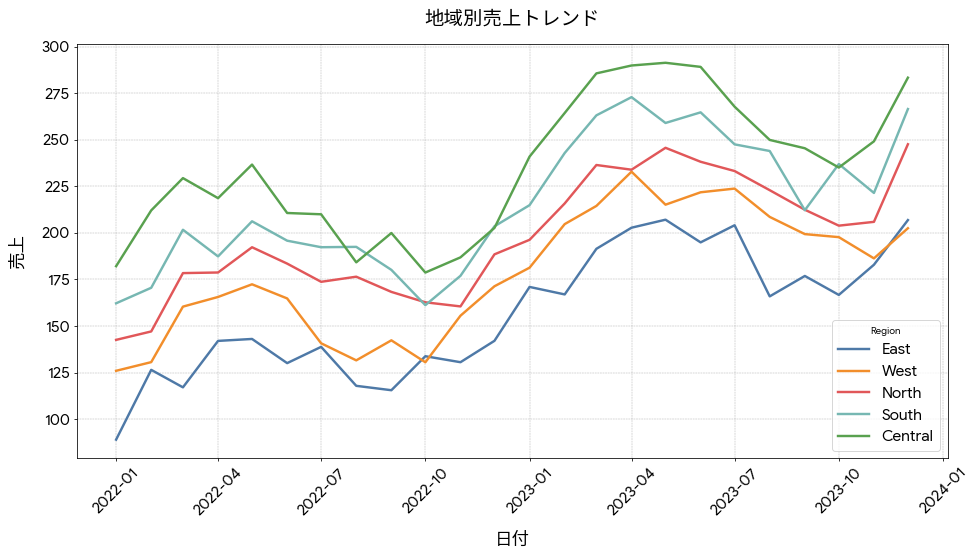

In [25]:
artifact_service = artifact_service_builder()
image_part = await artifact_service.load_artifact(
    app_name = 'root_agent',
    user_id = chat_client.user_id,
    session_id = chat_client.session_id,
    filename = 'output_plot.png'
)
display(Image.open(io.BytesIO(image_part.inline_data.data)))

In [26]:
session = await adk_app.async_get_session(
    user_id = chat_client.user_id,
    session_id = chat_client.session_id,
)    

In [27]:
session.state['qa_result']

{'interpreted_intent': 'The user wants to visualize the sales trends over time for each geographical region. The chart is intended for a corporate report for investors, so it needs to be clear, professional, and easy to understand.',
 'visualization_type': 'line chart',
 'plotting_key_points': ['Chart Type: A line chart to show trends over time.',
  "X-Axis: The 'Date' column, representing the timeline.",
  "Y-Axis: The 'Sales' column, representing the sales figures.",
  "Grouping: The data should be grouped by the 'Region' column. Each region will be represented by a separate line with a unique color.",
  "Data Processing: The 'Date' column must be converted to a datetime format to ensure correct plotting.",
  "Title: The chart should have a clear title in Japanese: '地域別売上トレンド' (Regional Sales Trends).",
  "Axis Labels: The x-axis should be labeled '日付' (Date) and the y-axis '売上' (Sales).",
  'Legend: A legend is required to identify which line corresponds to which region.',
  'Stylin

In [28]:
session.state['dp_result']

{'processing_steps': ["Load the 'sales_data.csv' file into a pandas DataFrame.",
  "Convert the 'Date' column from a string/object type to a datetime format to facilitate correct time-series plotting.",
  "Group the DataFrame by the 'Region' column to create distinct data subsets for each region, which will be plotted as separate lines."],
 'insights': {'key_columns': ['Date', 'Sales', 'Region'],
  'aggregations_needed': ["The data needs to be grouped by 'Region' to plot a separate line for each regional sales trend. No further numerical aggregation is required as the data is already presented at a monthly interval."],
  'quality_issues': ['No data quality issues, such as missing values or inconsistencies, were identified in the provided data sample. The data appears to be clean and ready for visualization.']},
 'visualization_hint': 'A line chart is the most suitable visualization for this data, as it effectively displays trends over a continuous variable (time) for different categori

In [29]:
session.state['vm_result']

{'chart_type': 'line',
 'data_mappings': {'x_axis': 'Date', 'y_axis': 'Sales', 'color': 'Region'},
 'aggregations': [],
 'filters': [],
 'styling_hints': {'title': '地域別売上トレンド',
  'xlabel': '日付',
  'ylabel': '売上',
  'color_palette': 'viridis'},
 'transformations': ["df['Date'] = pd.to_datetime(df['Date'])",
  "df.groupby('Region')"],
 'goal': 'This visualization will show the sales trends over time for each geographical region, allowing for a clear comparison of performance.',
 'rationale': "A line chart is the most effective way to display time-series data and compare trends across different categories (regions). Mapping 'Date' to the x-axis and 'Sales' to the y-axis is the standard convention for time-series analysis. Using the 'Region' column to color-code the lines allows for easy differentiation and comparison between the regions. This approach directly addresses the user's request to see regional sales trends over time.",
 'confidence': 1.0}

In [30]:
session.state['design_result']

{'design_objectives': ['Create a clear and professional visualization of regional sales trends over time.',
  'Ensure the chart is easily interpretable by investors, facilitating quick comparisons between regions.',
  'Maintain a clean, uncluttered aesthetic suitable for a formal corporate report.',
  'Guarantee high readability of all text elements, including title, labels, and legend, which will be in Japanese.'],
 'target_audience': {'primary_audience': 'Investors',
  'expertise_level': 'intermediate',
  'context_of_use': 'reporting',
  'accessibility_requirements': ['Colorblind-friendly palette']},
 'visual_hierarchy': {'primary_elements': ['The data lines representing the sales trends for each region.'],
  'secondary_elements': ['Chart Title',
   'Axis Labels',
   'Legend',
   'Grid lines',
   'Axis Ticks'],
  'emphasis_strategy': 'Emphasis will be achieved through the use of a distinct, high-contrast color for each data line, making them the focal point. The lines will have a gre

In [31]:
session.state['cg_result']

{'code_architecture': {'main_functions': ['generate_regional_sales_trend_chart: This function encapsulates the entire process of loading data, creating the plot, customizing it, and saving the final image.'],
  'helper_functions': [],
  'modular_design': 'The code is structured as a single, self-contained script with a main function to generate the plot. This is suitable for its specific purpose and avoids unnecessary complexity.'},
 'matplotlib_approach': {'plotting_method': 'object_oriented',
  'style_management': 'manual',
  'color_implementation': 'manual_colors',
  'layout_strategy': 'tight_layout'},
 'data_handling': {'data_preparation': ["Load 'sales_data.csv' into a pandas DataFrame.",
   "Convert the 'Date' column to datetime objects using pd.to_datetime."],
  'data_validation': ['A try-except block is used to handle the FileNotFoundError if the data file is not present.'],
  'error_handling': ['The script will print an error message and exit gracefully if the specified CSV fi

In [32]:
chat_client = ChatClient(adk_app)

with open('sales_data.csv', 'rb') as f:
    csv_bytes = f.read()

message_input = {
    'role': 'user',
    'parts': [
        {'text': '''
            2022年と2023年、それぞれの年度における地域ごとの売り上げの割合を見たい。
            各地域の担当責任者が出席する営業会議資料に掲載するので、最優秀地域が目立つように。
        '''},
        {
            'inline_data': {
                'mime_type': 'text/csv',
                'data': csv_bytes,
                'display_name': 'sales_data.csv',
            }
        },
    ]
}

response = await chat_client.async_stream_query(message_input)

### root_agent
承知いたしました。以下の情報で可視化を開始します。

*   **可視化クエリ**: 2022年と2023年、それぞれの年度における地域ごとの売り上げの割合を見たい。
*   **コンテキスト**: 各地域の担当責任者が出席する営業会議資料に掲載するので、最優秀地域が目立つように。
*   **データファイル**: sales_data.csv



### query_analyzer
{
  "interpreted_intent": "The user wants to visualize the proportion of sales for each region for the years 2022 and 2023. The visualization is for a sales meeting and should highlight the top-performing region for each year.",
  "visualization_type": "pie chart",
  "plotting_key_points": [
    "Create two separate pie charts, one for 2022 and one for 2023, arranged side-by-side.",
    "Each pie chart will show the sales breakdown by 'Region'.",
    "The size of each slice will represent the percentage of total sales for that region within that year.",
    "For each year, identify the region with the highest sales and make its corresponding slice 'explode' to make it stand out.",
    "Display the region name and percentage value on each slice.",
    "The titles for the charts and the overall figure should be in Japanese.",
    "The title for the 2022 chart should be '2022年 売上割合'.",
    "The title for the 2023 chart should be '2023年 売上割合'.",
    "The main title for the figure should be '年度別・地域別 売上割合'."
  ],
  "implementation_plan": [
    {
      "step": 1,
      "action": "Load and Prepare Data",
      "details": "Load the 'sales_data.csv' file into a pandas DataFrame. Convert the 'Date' column to datetime objects and extract the year into a new 'Year' column.",
      "functions": [
        "pd.read_csv",
        "pd.to_datetime"
      ]
    },
    {
      "step": 2,
      "action": "Process Data for Each Year",
      "details": "Create two separate dataframes, one for 2022 and one for 2023. For each year, group the data by 'Region' and calculate the sum of 'Sales'.",
      "functions": [
        "df.groupby",
        "df.sum"
      ]
    },
    {
      "step": 3,
      "action": "Set up the Plot",
      "details": "Create a matplotlib figure with two subplots in a 1x2 grid to accommodate the two pie charts.",
      "functions": [
        "plt.subplots"
      ]
    },
    {
      "step": 4,
      "action": "Generate 2022 Pie Chart",
      "details": "Using the 2022 aggregated data, plot a pie chart on the first subplot. Identify the top region and apply an 'explode' effect to its slice. Set the title to '2022年 売上割合'.",
      "functions": [
        "ax[0].pie"
      ]
    },
    {
      "step": 5,
      "action": "Generate 2023 Pie Chart",
      "details": "Using the 2023 aggregated data, plot a pie chart on the second subplot. Identify the top region and apply an 'explode' effect to its slice. Set the title to '2023年 売上割合'.",
      "functions": [
        "ax[1].pie"
      ]
    },
    {
      "step": 6,
      "action": "Finalize and Save Visualization",
      "details": "Add a main title '年度別・地域別 売上割合' to the entire figure. Ensure the layout is clean and not overlapping. Save the final plot to a file.",
      "functions": [
        "fig.suptitle",
        "plt.tight_layout",
        "plt.savefig"
      ]
    }
  ],
  "global_todo_list": [
    {
      "id": "todo_1",
      "task": "Analyze the data schema, extract the year from the 'Date' column, and define the data aggregation plan: group by Year and Region, then sum the Sales.",
      "agent": "data_process_planner"
    },
    {
      "id": "todo_2",
      "task": "Map the aggregated sales data to two pie charts. Define that each slice represents a region and its value is the sales sum. Specify the need for percentage labels.",
      "agent": "viz_mapping_agent"
    },
    {
      "id": "todo_3",
      "task": "Define a design strategy to highlight the top-performing region in each pie chart using an 'explode' effect. Select a suitable color palette and font sizes for a business presentation.",
      "agent": "design_explorer"
    },
    {
      "id": "todo_4",
      "task": "Generate Python code using pandas for data manipulation and matplotlib for plotting the two pie charts, including the logic to find and explode the largest slice in each.",
      "agent": "code_generator"
    },
    {
      "id": "todo_5",
      "task": "Evaluate the generated image to confirm that there are two pie charts for 2022 and 2023, the top region in each is correctly identified and exploded, and all labels and titles are present and in Japanese.",
      "agent": "visual_evaluator"
    }
  ],
  "success_criteria": [
    "The output must be a single image containing two pie charts, one for 2022 and one for 2023.",
    "Each pie chart must accurately represent the sales proportion by region for its respective year.",
    "The slice for the region with the highest sales must be visually exploded in each of the two charts.",
    "All text elements, including the main title, subplot titles, and slice labels, must be in Japanese.",
    "The visualization must be clear, professional, and easy to understand in a business meeting context."
  ]
}

### data_process_planner
{
  "processing_steps": [
    "Load the 'sales_data.csv' file into a pandas DataFrame.",
    "Convert the 'Date' column to datetime objects.",
    "Create a new 'Year' column by extracting the year from the 'Date' column.",
    "Filter the DataFrame to include only data from the years 2022 and 2023.",
    "Group the filtered data by 'Year' and 'Region', and then calculate the sum of 'Sales' for each group."
  ],
  "insights": {
    "key_columns": [
      "Date",
      "Region",
      "Sales"
    ],
    "aggregations_needed": [
      "Sum of sales by region for 2022",
      "Sum of sales by region for 2023"
    ],
    "quality_issues": [
      "No data quality issues were identified from the provided data preview. The data appears to be clean and ready for processing."
    ]
  },
  "visualization_hint": "Based on the data structure and the user's goal, creating two separate pie charts is the most effective way to visualize the sales proportions for each region in 2022 and 2023."
}

### viz_mapping_agent
{
  "chart_type": "pie",
  "data_mappings": {
    "x_axis": null,
    "y_axis": null,
    "color": "Region",
    "size": "Sales",
    "category": "Region"
  },
  "aggregations": [
    {
      "operation": "sum",
      "column": "Sales",
      "group_by": "Region"
    }
  ],
  "filters": [
    {
      "column": "Year",
      "condition": "== 2022"
    },
    {
      "column": "Year",
      "condition": "== 2023"
    }
  ],
  "styling_hints": {
    "title": "年度別・地域別 売上割合",
    "xlabel": null,
    "ylabel": null,
    "color_palette": "viridis"
  },
  "transformations": [
    "df['Date'] = pd.to_datetime(df['Date'])",
    "df['Year'] = df['Date'].dt.year",
    "df_2022 = df[df['Year'] == 2022]",
    "df_2023 = df[df['Year'] == 2023]",
    "sales_2022 = df_2022.groupby('Region')['Sales'].sum()",
    "sales_2023 = df_2023.groupby('Region')['Sales'].sum()"
  ],
  "goal": "To visualize and compare the proportion of sales for each region in 2022 and 2023, highlighting the top-performing region in each year.",
  "rationale": "The user requested to see the 'proportion of sales', for which a pie chart is the ideal visualization. Two separate charts are needed to compare the two years as requested. The data will be aggregated by summing the 'Sales' for each 'Region' for each year. The top-performing region will be highlighted by exploding the corresponding slice, as specified in the user's context.",
  "confidence": 1.0
}

### design_explorer
{
  "design_objectives": [
    "Clearly communicate the sales proportion for each region in 2022 and 2023.",
    "Draw immediate attention to the top-performing region in each year.",
    "Maintain a professional, clean, and uncluttered aesthetic suitable for a business presentation.",
    "Ensure the two charts are easily comparable."
  ],
  "target_audience": {
    "primary_audience": "Sales managers and regional heads attending a sales meeting.",
    "expertise_level": "intermediate",
    "context_of_use": "presentation",
    "accessibility_requirements": [
      "Colorblind-friendly palette to ensure all attendees can distinguish the regions."
    ]
  },
  "visual_hierarchy": {
    "primary_elements": [
      "The 'exploded' slice in each pie chart, representing the top-performing region."
    ],
    "secondary_elements": [
      "Percentage labels on each slice.",
      "The main title '年度別・地域別 売上割合'.",
      "The individual chart titles '2022年 売上割合' and '2023年 売上割合'."
    ],
    "emphasis_strategy": "The primary method of emphasis is the 'explode' effect, which creates spatial separation for the most important data point. This immediately guides the viewer's eye."
  },
  "color_strategy": {
    "primary_colors": [
      "#4E79A7",
      "#F28E2B",
      "#E15759",
      "#76B7B2",
      "#59A14F"
    ],
    "color_meaning": "Colors are used to categorically distinguish between the different sales regions. The same color will be used for the same region across both charts to maintain consistency and aid comparison. The palette is selected for its professional appearance and high contrast.",
    "accessibility_compliance": "WCAG 2.1 AA",
    "cultural_considerations": null
  },
  "layout_principles": {
    "composition_approach": "balanced",
    "spacing_strategy": "moderate",
    "alignment_system": "center",
    "proportion_ratios": "custom"
  },
  "typography_requirements": {
    "font_hierarchy": "Main Title: 20pt, bold. Subplot Titles: 18pt. Slice Labels (Region & Percentage): 16pt. A sans-serif font that supports Japanese characters is required for clarity and a modern feel.",
    "readability_priority": "high",
    "brand_alignment": "corporate"
  },
  "interaction_design": {
    "interaction_level": "static",
    "user_controls": [],
    "feedback_mechanisms": "None, as the visualization is a static image. All necessary information (region names, percentages) is directly labeled on the chart."
  },
  "technical_constraints": {
    "output_format": "static",
    "size_limitations": "screen",
    "performance_requirements": "fast"
  },
  "innovation_opportunities": [
    "Add a subtle drop shadow to the exploded slices to enhance the sense of depth and importance.",
    "Implement logic to prevent label overlap on smaller slices, possibly using leader lines if necessary to maintain readability."
  ],
  "design_confidence": 1.0
}

### code_generator
{
  "code_architecture": {
    "main_functions": [
      "Data Loading and Preparation",
      "Data Aggregation",
      "Pie Chart Plotting"
    ],
    "helper_functions": [
      "Identify top region for explode effect"
    ],
    "modular_design": "The code is structured sequentially, starting with data loading and preparation, followed by processing for each year, and finally plotting. This makes the script easy to follow from data input to visual output."
  },
  "matplotlib_approach": {
    "plotting_method": "plt.subplots",
    "style_management": "manual",
    "color_implementation": "manual_colors",
    "layout_strategy": "tight_layout"
  },
  "data_handling": {
    "data_preparation": [
      "Load 'sales_data.csv' into a pandas DataFrame.",
      "Convert 'Date' column to datetime objects.",
      "Extract the year into a new 'Year' column.",
      "Filter data for years 2022 and 2023.",
      "Group data by 'Region' and sum 'Sales' for each year."
    ],
    "data_validation": [
      "Ensured the 'Date' column is in a parsable format.",
      "Confirmed the presence of 'Region' and 'Sales' columns."
    ],
    "error_handling": [
      "The script assumes the 'sales_data.csv' file exists and is correctly formatted."
    ],
    "performance_considerations": [
      "The dataset is small, so performance is not a major concern. The use of pandas for data manipulation is efficient for this scale."
    ]
  },
  "code_structure": {
    "imports": [
      "import pandas as pd",
      "import matplotlib.pyplot as plt"
    ],
    "configuration": "The script sets up the figure and subplots using `plt.subplots(1, 2, figsize=(14, 7))`. Colors are manually defined in a dictionary to ensure consistency between the two plots.",
    "main_plotting": "Two pie charts are plotted on the two subplots (axes[0] and axes[1]). The `ax.pie()` function is used with parameters for data, labels, autopct for percentages, explode for highlighting the top region, and colors.",
    "customization": "Customizations include setting the main figure title with `fig.suptitle()`, subplot titles with `ax.set_title()`, and adjusting font sizes for titles and labels. The `explode` parameter is dynamically set to highlight the top-performing region in each year.",
    "output_handling": "The final visualization is saved to a file named 'output_plot.png' using `plt.savefig()` with a specified DPI, and all plot figures are closed using `plt.close('all')`."
  },
  "quality_requirements": {
    "code_style": "PEP8",
    "documentation_level": "minimal",
    "error_handling_level": "basic",
    "performance_priority": "readability"
  },
  "generated_code": "\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# Load the data\ndf = pd.read_csv('sales_data.csv')\n\n# Data Preparation\ndf['Date'] = pd.to_datetime(df['Date'])\ndf['Year'] = df['Date'].dt.year\n\n# Filter and aggregate data for 2022 and 2023\nsales_2022 = df[df['Year'] == 2022].groupby('Region')['Sales'].sum()\nsales_2023 = df[df['Year'] == 2023].groupby('Region')['Sales'].sum()\n\n# Identify the top region for each year\ntop_region_2022 = sales_2022.idxmax()\ntop_region_2023 = sales_2023.idxmax()\n\n# Create explode lists\nexplode_2022 = [0.1 if region == top_region_2022 else 0 for region in sales_2022.index]\nexplode_2023 = [0.1 if region == top_region_2023 else 0 for region in sales_2023.index]\n\n# Define colors for consistency\ncolors = {'North': '#4E79A7', 'South': '#F28E2B', 'East': '#E15759', 'West': '#76B7B2', 'Central': '#59A14F'}\ncolors_2022 = [colors[region] for region in sales_2022.index]\ncolors_2023 = [colors[region] for region in sales_2023.index]\n\n\n# Create the plot\nfig, axes = plt.subplots(1, 2, figsize=(14, 7))\n\n# Plot 2022 Pie Chart\nwedges_2022, texts_2022, autotexts_2022 = axes[0].pie(\n    sales_2022, \n    labels=sales_2022.index, \n    autopct='%1.1f%%', \n    explode=explode_2022, \n    colors=colors_2022,\n    textprops={'fontsize': 16}\n)\naxes[0].set_title('2022年 売上割合', fontsize=18)\n\n# Plot 2023 Pie Chart\nwedges_2023, texts_2023, autotexts_2023 = axes[1].pie(\n    sales_2023, \n    labels=sales_2023.index, \n    autopct='%1.1f%%', \n    explode=explode_2023, \n    colors=colors_2023,\n    textprops={'fontsize': 16}\n)\naxes[1].set_title('2023年 売上割合', fontsize=18)\n\n# Set main title\nfig.suptitle('年度別・地域別 売上割合', fontsize=20, fontweight='bold')\n\n# Finalize and save\nplt.tight_layout(rect=[0, 0, 1, 0.96])\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')\n"
}

### transfer_agent
#### Pipeline execution result:
* Available Data Files: ['sales_data.csv']

* Result from the `query_analyser`:
{'interpreted_intent': 'The user wants to visualize the proportion of sales for each region for the years 2022 and 2023. The visualization is for a sales meeting and should highlight the top-performing region for each year.', 'visualization_type': 'pie chart', 'plotting_key_points': ['Create two separate pie charts, one for 2022 and one for 2023, arranged side-by-side.', "Each pie chart will show the sales breakdown by 'Region'.", 'The size of each slice will represent the percentage of total sales for that region within that year.', "For each year, identify the region with the highest sales and make its corresponding slice 'explode' to make it stand out.", 'Display the region name and percentage value on each slice.', 'The titles for the charts and the overall figure should be in Japanese.', "The title for the 2022 chart should be '2022年 売上割合'.", "The title for the 2023 chart should be '2023年 売上割合'.", "The main title for the figure should be '年度別・地域別 売上割合'."], 'implementation_plan': [{'step': 1, 'action': 'Load and Prepare Data', 'details': "Load the 'sales_data.csv' file into a pandas DataFrame. Convert the 'Date' column to datetime objects and extract the year into a new 'Year' column.", 'functions': ['pd.read_csv', 'pd.to_datetime']}, {'step': 2, 'action': 'Process Data for Each Year', 'details': "Create two separate dataframes, one for 2022 and one for 2023. For each year, group the data by 'Region' and calculate the sum of 'Sales'.", 'functions': ['df.groupby', 'df.sum']}, {'step': 3, 'action': 'Set up the Plot', 'details': 'Create a matplotlib figure with two subplots in a 1x2 grid to accommodate the two pie charts.', 'functions': ['plt.subplots']}, {'step': 4, 'action': 'Generate 2022 Pie Chart', 'details': "Using the 2022 aggregated data, plot a pie chart on the first subplot. Identify the top region and apply an 'explode' effect to its slice. Set the title to '2022年 売上割合'.", 'functions': ['ax[0].pie']}, {'step': 5, 'action': 'Generate 2023 Pie Chart', 'details': "Using the 2023 aggregated data, plot a pie chart on the second subplot. Identify the top region and apply an 'explode' effect to its slice. Set the title to '2023年 売上割合'.", 'functions': ['ax[1].pie']}, {'step': 6, 'action': 'Finalize and Save Visualization', 'details': "Add a main title '年度別・地域別 売上割合' to the entire figure. Ensure the layout is clean and not overlapping. Save the final plot to a file.", 'functions': ['fig.suptitle', 'plt.tight_layout', 'plt.savefig']}], 'global_todo_list': [{'id': 'todo_1', 'task': "Analyze the data schema, extract the year from the 'Date' column, and define the data aggregation plan: group by Year and Region, then sum the Sales.", 'agent': 'data_process_planner'}, {'id': 'todo_2', 'task': 'Map the aggregated sales data to two pie charts. Define that each slice represents a region and its value is the sales sum. Specify the need for percentage labels.', 'agent': 'viz_mapping_agent'}, {'id': 'todo_3', 'task': "Define a design strategy to highlight the top-performing region in each pie chart using an 'explode' effect. Select a suitable color palette and font sizes for a business presentation.", 'agent': 'design_explorer'}, {'id': 'todo_4', 'task': 'Generate Python code using pandas for data manipulation and matplotlib for plotting the two pie charts, including the logic to find and explode the largest slice in each.', 'agent': 'code_generator'}, {'id': 'todo_5', 'task': 'Evaluate the generated image to confirm that there are two pie charts for 2022 and 2023, the top region in each is correctly identified and exploded, and all labels and titles are present and in Japanese.', 'agent': 'visual_evaluator'}], 'success_criteria': ['The output must be a single image containing two pie charts, one for 2022 and one for 2023.', 'Each pie chart must accurately represent the sales proportion by region for its respective year.', 'The slice for the region with the highest sales must be visually exploded in each of the two charts.', 'All text elements, including the main title, subplot titles, and slice labels, must be in Japanese.', 'The visualization must be clear, professional, and easy to understand in a business meeting context.']}
* Result from the `data_process_planner`:
{'processing_steps': ["Load the 'sales_data.csv' file into a pandas DataFrame.", "Convert the 'Date' column to datetime objects.", "Create a new 'Year' column by extracting the year from the 'Date' column.", 'Filter the DataFrame to include only data from the years 2022 and 2023.', "Group the filtered data by 'Year' and 'Region', and then calculate the sum of 'Sales' for each group."], 'insights': {'key_columns': ['Date', 'Region', 'Sales'], 'aggregations_needed': ['Sum of sales by region for 2022', 'Sum of sales by region for 2023'], 'quality_issues': ['No data quality issues were identified from the provided data preview. The data appears to be clean and ready for processing.']}, 'visualization_hint': "Based on the data structure and the user's goal, creating two separate pie charts is the most effective way to visualize the sales proportions for each region in 2022 and 2023."}
* Result from the `viz_mapping_agent`:
{'chart_type': 'pie', 'data_mappings': {'color': 'Region', 'size': 'Sales', 'category': 'Region'}, 'aggregations': [{'operation': 'sum', 'column': 'Sales', 'group_by': 'Region'}], 'filters': [{'column': 'Year', 'condition': '== 2022'}, {'column': 'Year', 'condition': '== 2023'}], 'styling_hints': {'title': '年度別・地域別 売上割合', 'color_palette': 'viridis'}, 'transformations': ["df['Date'] = pd.to_datetime(df['Date'])", "df['Year'] = df['Date'].dt.year", "df_2022 = df[df['Year'] == 2022]", "df_2023 = df[df['Year'] == 2023]", "sales_2022 = df_2022.groupby('Region')['Sales'].sum()", "sales_2023 = df_2023.groupby('Region')['Sales'].sum()"], 'goal': 'To visualize and compare the proportion of sales for each region in 2022 and 2023, highlighting the top-performing region in each year.', 'rationale': "The user requested to see the 'proportion of sales', for which a pie chart is the ideal visualization. Two separate charts are needed to compare the two years as requested. The data will be aggregated by summing the 'Sales' for each 'Region' for each year. The top-performing region will be highlighted by exploding the corresponding slice, as specified in the user's context.", 'confidence': 1.0}
* Result from the `design_explorer`:
{'design_objectives': ['Clearly communicate the sales proportion for each region in 2022 and 2023.', 'Draw immediate attention to the top-performing region in each year.', 'Maintain a professional, clean, and uncluttered aesthetic suitable for a business presentation.', 'Ensure the two charts are easily comparable.'], 'target_audience': {'primary_audience': 'Sales managers and regional heads attending a sales meeting.', 'expertise_level': 'intermediate', 'context_of_use': 'presentation', 'accessibility_requirements': ['Colorblind-friendly palette to ensure all attendees can distinguish the regions.']}, 'visual_hierarchy': {'primary_elements': ["The 'exploded' slice in each pie chart, representing the top-performing region."], 'secondary_elements': ['Percentage labels on each slice.', "The main title '年度別・地域別 売上割合'.", "The individual chart titles '2022年 売上割合' and '2023年 売上割合'."], 'emphasis_strategy': "The primary method of emphasis is the 'explode' effect, which creates spatial separation for the most important data point. This immediately guides the viewer's eye."}, 'color_strategy': {'primary_colors': ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F'], 'color_meaning': 'Colors are used to categorically distinguish between the different sales regions. The same color will be used for the same region across both charts to maintain consistency and aid comparison. The palette is selected for its professional appearance and high contrast.', 'accessibility_compliance': 'WCAG 2.1 AA'}, 'layout_principles': {'composition_approach': 'balanced', 'spacing_strategy': 'moderate', 'alignment_system': 'center', 'proportion_ratios': 'custom'}, 'typography_requirements': {'font_hierarchy': 'Main Title: 20pt, bold. Subplot Titles: 18pt. Slice Labels (Region & Percentage): 16pt. A sans-serif font that supports Japanese characters is required for clarity and a modern feel.', 'readability_priority': 'high', 'brand_alignment': 'corporate'}, 'interaction_design': {'interaction_level': 'static', 'user_controls': [], 'feedback_mechanisms': 'None, as the visualization is a static image. All necessary information (region names, percentages) is directly labeled on the chart.'}, 'technical_constraints': {'output_format': 'static', 'size_limitations': 'screen', 'performance_requirements': 'fast'}, 'innovation_opportunities': ['Add a subtle drop shadow to the exploded slices to enhance the sense of depth and importance.', 'Implement logic to prevent label overlap on smaller slices, possibly using leader lines if necessary to maintain readability.'], 'design_confidence': 1.0}
* Result from the `code_generator`:
{'code_architecture': {'main_functions': ['Data Loading and Preparation', 'Data Aggregation', 'Pie Chart Plotting'], 'helper_functions': ['Identify top region for explode effect'], 'modular_design': 'The code is structured sequentially, starting with data loading and preparation, followed by processing for each year, and finally plotting. This makes the script easy to follow from data input to visual output.'}, 'matplotlib_approach': {'plotting_method': 'plt.subplots', 'style_management': 'manual', 'color_implementation': 'manual_colors', 'layout_strategy': 'tight_layout'}, 'data_handling': {'data_preparation': ["Load 'sales_data.csv' into a pandas DataFrame.", "Convert 'Date' column to datetime objects.", "Extract the year into a new 'Year' column.", 'Filter data for years 2022 and 2023.', "Group data by 'Region' and sum 'Sales' for each year."], 'data_validation': ["Ensured the 'Date' column is in a parsable format.", "Confirmed the presence of 'Region' and 'Sales' columns."], 'error_handling': ["The script assumes the 'sales_data.csv' file exists and is correctly formatted."], 'performance_considerations': ['The dataset is small, so performance is not a major concern. The use of pandas for data manipulation is efficient for this scale.']}, 'code_structure': {'imports': ['import pandas as pd', 'import matplotlib.pyplot as plt'], 'configuration': 'The script sets up the figure and subplots using `plt.subplots(1, 2, figsize=(14, 7))`. Colors are manually defined in a dictionary to ensure consistency between the two plots.', 'main_plotting': 'Two pie charts are plotted on the two subplots (axes[0] and axes[1]). The `ax.pie()` function is used with parameters for data, labels, autopct for percentages, explode for highlighting the top region, and colors.', 'customization': 'Customizations include setting the main figure title with `fig.suptitle()`, subplot titles with `ax.set_title()`, and adjusting font sizes for titles and labels. The `explode` parameter is dynamically set to highlight the top-performing region in each year.', 'output_handling': "The final visualization is saved to a file named 'output_plot.png' using `plt.savefig()` with a specified DPI, and all plot figures are closed using `plt.close('all')`."}, 'quality_requirements': {'code_style': 'PEP8', 'documentation_level': 'minimal', 'error_handling_level': 'basic', 'performance_priority': 'readability'}, 'generated_code': "\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# Load the data\ndf = pd.read_csv('sales_data.csv')\n\n# Data Preparation\ndf['Date'] = pd.to_datetime(df['Date'])\ndf['Year'] = df['Date'].dt.year\n\n# Filter and aggregate data for 2022 and 2023\nsales_2022 = df[df['Year'] == 2022].groupby('Region')['Sales'].sum()\nsales_2023 = df[df['Year'] == 2023].groupby('Region')['Sales'].sum()\n\n# Identify the top region for each year\ntop_region_2022 = sales_2022.idxmax()\ntop_region_2023 = sales_2023.idxmax()\n\n# Create explode lists\nexplode_2022 = [0.1 if region == top_region_2022 else 0 for region in sales_2022.index]\nexplode_2023 = [0.1 if region == top_region_2023 else 0 for region in sales_2023.index]\n\n# Define colors for consistency\ncolors = {'North': '#4E79A7', 'South': '#F28E2B', 'East': '#E15759', 'West': '#76B7B2', 'Central': '#59A14F'}\ncolors_2022 = [colors[region] for region in sales_2022.index]\ncolors_2023 = [colors[region] for region in sales_2023.index]\n\n\n# Create the plot\nfig, axes = plt.subplots(1, 2, figsize=(14, 7))\n\n# Plot 2022 Pie Chart\nwedges_2022, texts_2022, autotexts_2022 = axes[0].pie(\n    sales_2022, \n    labels=sales_2022.index, \n    autopct='%1.1f%%', \n    explode=explode_2022, \n    colors=colors_2022,\n    textprops={'fontsize': 16}\n)\naxes[0].set_title('2022年 売上割合', fontsize=18)\n\n# Plot 2023 Pie Chart\nwedges_2023, texts_2023, autotexts_2023 = axes[1].pie(\n    sales_2023, \n    labels=sales_2023.index, \n    autopct='%1.1f%%', \n    explode=explode_2023, \n    colors=colors_2023,\n    textprops={'fontsize': 16}\n)\naxes[1].set_title('2023年 売上割合', fontsize=18)\n\n# Set main title\nfig.suptitle('年度別・地域別 売上割合', fontsize=20, fontweight='bold')\n\n# Finalize and save\nplt.tight_layout(rect=[0, 0, 1, 0.96])\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')\n"}


### root_agent
2022年と2023年の地域別売上割合を示す2つの円グラフが生成されました。各年の最も売上が高かった地域は強調表示されています。

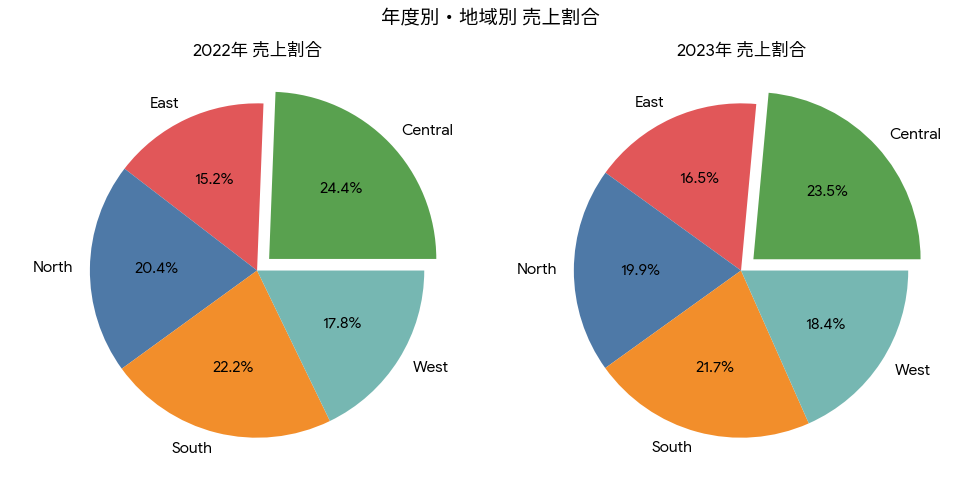

In [33]:
artifact_service = artifact_service_builder()
image_part = await artifact_service.load_artifact(
    app_name = 'root_agent',
    user_id = chat_client.user_id,
    session_id = chat_client.session_id,
    filename = 'output_plot.png'
)
display(Image.open(io.BytesIO(image_part.inline_data.data)))

In [34]:
session = await adk_app.async_get_session(
    user_id = chat_client.user_id,
    session_id = chat_client.session_id,
)    

In [35]:
session.state['qa_result']

{'interpreted_intent': 'The user wants to visualize the proportion of sales for each region for the years 2022 and 2023. The visualization is for a sales meeting and should highlight the top-performing region for each year.',
 'visualization_type': 'pie chart',
 'plotting_key_points': ['Create two separate pie charts, one for 2022 and one for 2023, arranged side-by-side.',
  "Each pie chart will show the sales breakdown by 'Region'.",
  'The size of each slice will represent the percentage of total sales for that region within that year.',
  "For each year, identify the region with the highest sales and make its corresponding slice 'explode' to make it stand out.",
  'Display the region name and percentage value on each slice.',
  'The titles for the charts and the overall figure should be in Japanese.',
  "The title for the 2022 chart should be '2022年 売上割合'.",
  "The title for the 2023 chart should be '2023年 売上割合'.",
  "The main title for the figure should be '年度別・地域別 売上割合'."],
 'impl

In [36]:
session.state['dp_result']

{'processing_steps': ["Load the 'sales_data.csv' file into a pandas DataFrame.",
  "Convert the 'Date' column to datetime objects.",
  "Create a new 'Year' column by extracting the year from the 'Date' column.",
  'Filter the DataFrame to include only data from the years 2022 and 2023.',
  "Group the filtered data by 'Year' and 'Region', and then calculate the sum of 'Sales' for each group."],
 'insights': {'key_columns': ['Date', 'Region', 'Sales'],
  'aggregations_needed': ['Sum of sales by region for 2022',
   'Sum of sales by region for 2023'],
  'quality_issues': ['No data quality issues were identified from the provided data preview. The data appears to be clean and ready for processing.']},
 'visualization_hint': "Based on the data structure and the user's goal, creating two separate pie charts is the most effective way to visualize the sales proportions for each region in 2022 and 2023."}

In [37]:
session.state['vm_result']

{'chart_type': 'pie',
 'data_mappings': {'color': 'Region', 'size': 'Sales', 'category': 'Region'},
 'aggregations': [{'operation': 'sum',
   'column': 'Sales',
   'group_by': 'Region'}],
 'filters': [{'column': 'Year', 'condition': '== 2022'},
  {'column': 'Year', 'condition': '== 2023'}],
 'styling_hints': {'title': '年度別・地域別 売上割合', 'color_palette': 'viridis'},
 'transformations': ["df['Date'] = pd.to_datetime(df['Date'])",
  "df['Year'] = df['Date'].dt.year",
  "df_2022 = df[df['Year'] == 2022]",
  "df_2023 = df[df['Year'] == 2023]",
  "sales_2022 = df_2022.groupby('Region')['Sales'].sum()",
  "sales_2023 = df_2023.groupby('Region')['Sales'].sum()"],
 'goal': 'To visualize and compare the proportion of sales for each region in 2022 and 2023, highlighting the top-performing region in each year.',
 'rationale': "The user requested to see the 'proportion of sales', for which a pie chart is the ideal visualization. Two separate charts are needed to compare the two years as requested. The

In [38]:
session.state['design_result']

{'design_objectives': ['Clearly communicate the sales proportion for each region in 2022 and 2023.',
  'Draw immediate attention to the top-performing region in each year.',
  'Maintain a professional, clean, and uncluttered aesthetic suitable for a business presentation.',
  'Ensure the two charts are easily comparable.'],
 'target_audience': {'primary_audience': 'Sales managers and regional heads attending a sales meeting.',
  'expertise_level': 'intermediate',
  'context_of_use': 'presentation',
  'accessibility_requirements': ['Colorblind-friendly palette to ensure all attendees can distinguish the regions.']},
 'visual_hierarchy': {'primary_elements': ["The 'exploded' slice in each pie chart, representing the top-performing region."],
  'secondary_elements': ['Percentage labels on each slice.',
   "The main title '年度別・地域別 売上割合'.",
   "The individual chart titles '2022年 売上割合' and '2023年 売上割合'."],
  'emphasis_strategy': "The primary method of emphasis is the 'explode' effect, which 

In [39]:
session.state['cg_result']

{'code_architecture': {'main_functions': ['Data Loading and Preparation',
   'Data Aggregation',
   'Pie Chart Plotting'],
  'helper_functions': ['Identify top region for explode effect'],
  'modular_design': 'The code is structured sequentially, starting with data loading and preparation, followed by processing for each year, and finally plotting. This makes the script easy to follow from data input to visual output.'},
 'matplotlib_approach': {'plotting_method': 'plt.subplots',
  'style_management': 'manual',
  'color_implementation': 'manual_colors',
  'layout_strategy': 'tight_layout'},
 'data_handling': {'data_preparation': ["Load 'sales_data.csv' into a pandas DataFrame.",
   "Convert 'Date' column to datetime objects.",
   "Extract the year into a new 'Year' column.",
   'Filter data for years 2022 and 2023.',
   "Group data by 'Region' and sum 'Sales' for each year."],
  'data_validation': ["Ensured the 'Date' column is in a parsable format.",
   "Confirmed the presence of 'Reg